# DSQI — Complete DNA Storage Quality Index Project

## Metric-correct, documented Google Colab implementation

This notebook is a complete, evidence-first implementation of the supplied DSQI plan, revised using the attached **DSQI v3 Publication** notebook. It retains useful v3 ideas—target-reliability diagnostics, FCGR/CGR sequence representations, feature-family analysis, bootstrap intervals, ablation ladders, fold-wise classification labels, and a deployable closed-form DSQI—while correcting the principal risks identified in the audit.

| Audit issue addressed | Correction in this notebook |
|---|---|
| Silent simulated fallback | Real-data mode is fail-closed. No synthetic observations are used for scientific results. |
| Selection leakage | The primary target definition is fixed before modeling; OOF models, DSQI weights, class thresholds, and feature importance are fit inside training folds. |
| Ambiguous alignment | The target is mean normalized **global Levenshtein distance**. A global affine-gap implementation is tested separately as a sensitivity method; local Smith–Waterman is not used for whole-read error. |
| Uncertainty gaps | Bootstrap confidence intervals are reported for regression, correlation, DSQI, and paired ablation differences. |
| Overclaiming DSQI | DSQI is evaluated out of fold, bounded to 0–100, and compared with an independent OOF model referee. |
| Stale publication outputs | The notebook starts with empty outputs and writes a fresh run manifest, checksums, configuration, tables, and figures. |

> **Important interpretation.** The default data source is the public Microsoft Clustered Nanopore Reads benchmark. The default target is a read-to-reference error proxy measured from real released reads. Results are valid for the selected dataset and configuration; they are not universal biological laws.

### Overall architecture / mind map

```text
Public DNA reads + references
            |
            v
   Provenance + schema checks
            |
            v
  Spark RDD -> DataFrame -> SQL
            |
            v
  Reference-only feature engineering
   /       |        |        \
 sequence  k-mers  FCGR    QC metrics
            |
            v
   OOF statistics and MLlib/sklearn models
            |
      +-----+------+----------------+
      |            |                |
 regression   classification   clustering
      |            |                |
      +------------+----------------+
                   v
          feature importance
                   |
          similarity graph
                   |
       fold-safe DSQI construction
                   |
       validation + dashboard + export
```

## 01. Environment setup

**Why this step is used.** Spark, Python, Java, and the optional image/ML libraries must be known before any timing or metric is interpreted. A reproducible notebook records versions and seeds at the start.

**Alternatives considered.** A managed Spark cluster would provide genuine distributed execution, but Google Colab normally exposes only a local VM. This notebook uses local Spark intentionally for API and workflow demonstration and reports that limitation explicitly.

**Architecture view.**

```text
Colab runtime -> dependency check -> SparkSession + SparkContext -> reproducibility record
```

In [ ]:
# Run once in a fresh Colab runtime. The command is intentionally visible for reproducibility.
# Dependencies installed in smoke-test environment

import os, sys, json, math, time, random, hashlib, shutil, subprocess, warnings, re
from pathlib import Path
from collections import Counter, defaultdict

os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'
os.environ['PYSPARK_PYTHON'] = sys.executable
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import nnls

from pyspark.sql import SparkSession, Row, functions as F, types as T
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler as SparkStandardScaler
from pyspark.ml.regression import LinearRegression as SparkLinearRegression, RandomForestRegressor as SparkRandomForestRegressor
from pyspark.ml.classification import LogisticRegression as SparkLogisticRegression, RandomForestClassifier as SparkRandomForestClassifier
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator, ClusteringEvaluator

from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, RandomForestClassifier
from sklearn.cluster import KMeans as SKKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, balanced_accuracy_score,
                             precision_recall_fscore_support, f1_score, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                             silhouette_score)

try:
    from rapidfuzz.distance import Levenshtein as RFLevenshtein
    HAVE_RAPIDFUZZ = True
except Exception:
    HAVE_RAPIDFUZZ = False

try:
    import networkx as nx
except Exception:
    nx = None

SEED = 4262
np.random.seed(SEED)
random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.titlesize': 11})

# Change only these controls for a larger run. MAX_CENTERS=None means the full public release.
MAX_CENTERS = 80
MAX_READS_PER_CENTER = 15
PRIMARY_MIN_READS = 8
PRIMARY_REDUCER = 'mean'
N_FOLDS = 5
N_BOOT = 60
GRAPH_N = 60
PERM_REPEATS = 1

PROJECT_ROOT = Path('/home/ubuntu/DSQI_complete_smoke')
USE_DRIVE = False
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/DSQI_Project')

for p in [PROJECT_ROOT/'data/raw', PROJECT_ROOT/'data/processed', PROJECT_ROOT/'data/external',
          PROJECT_ROOT/'models', PROJECT_ROOT/'outputs/figures', PROJECT_ROOT/'outputs/tables',
          PROJECT_ROOT/'outputs/predictions', PROJECT_ROOT/'reports']:
    p.mkdir(parents=True, exist_ok=True)

spark = (SparkSession.builder.appName('DSQI-Complete')
         .master('local[*]').config('spark.sql.shuffle.partitions', '8')
         .config('spark.driver.memory', '4g').getOrCreate())
sc = spark.sparkContext
sc.setLogLevel('WARN')

print('Python:', sys.version.split()[0])
print('PySpark/Spark:', spark.version)
print('Master:', sc.master)
print('Java:', subprocess.check_output(['java','-version'], stderr=subprocess.STDOUT, text=True).splitlines()[0])
print('RapidFuzz:', HAVE_RAPIDFUZZ)
print('CPU:', os.cpu_count(), 'Disk free GB:', round(shutil.disk_usage(PROJECT_ROOT).free/1e9, 2))
print('SparkSession:', spark)
print('SparkContext:', sc)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/24 08:10:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Python: 3.12.3
PySpark/Spark: 3.5.1
Master: local[*]
Java: openjdk version "21.0.11" 2026-04-21
RapidFuzz: False
CPU: 6 Disk free GB: 31.8
SparkSession: <pyspark.sql.session.SparkSession object at 0x7fd916d622d0>
SparkContext: <SparkContext master=local[*] appName=DSQI-Complete>


## 02. Data provenance, acquisition, and schema

**Why this step is used.** A metric is only meaningful when the reference sequence, read sequence, cluster identity, and source provenance are explicit. The CNR release documents that `Centers.txt` and `Clusters.txt` correspond by position and that the reads are noisy Oxford Nanopore traces.

**Alternatives considered.** The public DNAformer repository is inspected as a secondary source, but its README says the full experimental datasets are shared on request. It therefore cannot supply a complete labeled external-validation table by default. The notebook does not replace missing labels with simulated values.

**Architecture view.**

```text
CNR URLs or Drive files -> checksum -> defensive parser -> aligned reference/read clusters
DNAformer sample        -> optional inspection only -> provenance manifest
```

In [ ]:
import requests

CNR_URLS = {
    'centers': 'https://raw.githubusercontent.com/microsoft/clustered-nanopore-reads-dataset/main/Centers.txt',
    'clusters': 'https://raw.githubusercontent.com/microsoft/clustered-nanopore-reads-dataset/main/Clusters.txt',
}
DNAFORMER_URLS = {
    'fastq': 'https://raw.githubusercontent.com/itaiorr/Deep-DNA-based-storage/main/DeepEncoderDecoder/data/fastq_runid_f9875c0bb5171f8bae2f76aa5d9ac39431889861_1_0.fastq',
    'design': 'https://raw.githubusercontent.com/itaiorr/Deep-DNA-based-storage/main/DeepEncoderDecoder/deep_design.csv',
}
RAW_DIR = PROJECT_ROOT/'data/raw'
CENTERS_PATH, CLUSTERS_PATH = RAW_DIR/'Centers.txt', RAW_DIR/'Clusters.txt'
DNAFORMER_FASTQ, DNAFORMER_DESIGN = RAW_DIR/'dnaformer_sample.fastq', RAW_DIR/'dnaformer_deep_design.csv'

def download(url, path):
    path = Path(path)
    if path.exists() and path.stat().st_size > 0:
        return path
    r = requests.get(url, stream=True, timeout=180)
    r.raise_for_status()
    with open(path, 'wb') as f:
        for chunk in r.iter_content(1024*1024):
            if chunk: f.write(chunk)
    return path

def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for b in iter(lambda: f.read(1024*1024), b''): h.update(b)
    return h.hexdigest()

# Fail closed if the primary real data cannot be obtained.
for key, url in CNR_URLS.items():
    download(url, {'centers': CENTERS_PATH, 'clusters': CLUSTERS_PATH}[key])
for key, url in DNAFORMER_URLS.items():
    try:
        download(url, {'fastq': DNAFORMER_FASTQ, 'design': DNAFORMER_DESIGN}[key])
    except Exception as e:
        print('Optional DNAformer file unavailable:', key, e)

manifest = []
for p, source, purpose in [(CENTERS_PATH,'Microsoft CNR','reference sequences'),
                           (CLUSTERS_PATH,'Microsoft CNR','noisy reads'),
                           (DNAFORMER_FASTQ,'DNAformer GitHub','sample inspection'),
                           (DNAFORMER_DESIGN,'DNAformer GitHub','design inspection')]:
    if Path(p).exists():
        manifest.append({'file': str(p), 'source': source, 'purpose': purpose,
                         'size_bytes': Path(p).stat().st_size, 'sha256': sha256(p)})
manifest_pd = pd.DataFrame(manifest)
manifest_pd.to_csv(PROJECT_ROOT/'outputs/tables/dataset_manifest.csv', index=False)
display(manifest_pd)

VALID = set('ACGT')
def parse_centers(path):
    out = []
    with open(path) as f:
        for line in f:
            s = line.strip().upper()
            if s and set(s) <= VALID: out.append(s)
    return out

def parse_clusters(path, n_centers):
    blocks, current = [], []
    with open(path) as f:
        for line in f:
            s = line.strip().upper()
            if s.startswith('='):
                blocks.append(current); current = []
            elif s and set(s) <= VALID:
                current.append(s)
    blocks.append(current)
    # CNR has one block per center. Align by documented positional order.
    if len(blocks) < n_centers:
        blocks += [[] for _ in range(n_centers-len(blocks))]
    return blocks[:n_centers]

centers_all = parse_centers(CENTERS_PATH)
clusters_all = parse_clusters(CLUSTERS_PATH, len(centers_all))
if MAX_CENTERS is None:
    selected = np.arange(len(centers_all))
else:
    selected = np.arange(min(MAX_CENTERS, len(centers_all)))
centers = [centers_all[i] for i in selected]
clusters = [[r for r in clusters_all[i][:MAX_READS_PER_CENTER]] for i in selected]

print('Centers selected:', len(centers), '/', len(centers_all))
print('Reads retained:', sum(map(len, clusters)))
print('Empty clusters:', sum(len(x)==0 for x in clusters))
print('Reference lengths:', Counter(map(len, centers)).most_common(10))
print('Coverage summary:', pd.Series([len(x) for x in clusters]).describe().round(3).to_dict())

# Optional DNAformer inspection; these records are not treated as labeled outcomes.
def preview_fastq(path, n=5):
    rows=[]
    if not Path(path).exists(): return pd.DataFrame()
    with open(path) as f:
        for _ in range(n):
            h, s, plus, q = f.readline().strip(), f.readline().strip(), f.readline().strip(), f.readline().strip()
            if not h or not s: break
            rows.append({'header':h, 'sequence':s, 'quality_length':len(q)})
    return pd.DataFrame(rows)
print('DNAformer sample preview:')
display(preview_fastq(DNAFORMER_FASTQ))

,file,source,purpose,size_bytes,sha256
0,/home/ubuntu/DSQI_complete_smoke/data/raw/Cent...,Microsoft CNR,reference sequences,1120000,b70e723ef0d83a88f7b3e483b932b0279628a0eae39cb4...
1,/home/ubuntu/DSQI_complete_smoke/data/raw/Clus...,Microsoft CNR,noisy reads,30452518,7c2e27b497762ed3bb01a2d27ed09ca2291d590a0a7534...
2,/home/ubuntu/DSQI_complete_smoke/data/raw/dnaf...,DNAformer GitHub,sample inspection,2108941,26daf86e61a9b2291a4d8c34bb081ae9560ceeefcedc88...
3,/home/ubuntu/DSQI_complete_smoke/data/raw/dnaf...,DNAformer GitHub,design inspection,16940017,14a392c3fe36a72e74f49a48c07578738d61032fd84cbd...


Centers selected: 80 / 10000
Reads retained: 1093
Empty clusters: 1
Reference lengths: [(110, 80)]
Coverage summary: {'count': 80.0, 'mean': 13.662, 'std': 2.801, 'min': 0.0, '25%': 14.75, '50%': 15.0, '75%': 15.0, 'max': 15.0}
DNAformer sample preview:


,header,sequence,quality_length
0,@c146fb1b-1bea-4101-a17c-5a7a664cf4f2 runid=f9...,AACATCCAGCTTGTACTTCGTTCAGTTGCATGCTTCGTCGGCAGCG...,246
1,@b9810eb6-40e7-4707-a4ce-78d1d2856041 runid=f9...,ACCTCCTTGTACTTCGTTCAGTTACGTATTGCTGTCTCGTGGGCTC...,250
2,@215974a3-24e7-42db-ae47-ed7792fd6212 runid=f9...,TTGTACTTCGTTCAGTTACGTATTGCTGTCGGCAGCGTCAGATGTG...,239
3,@cf266d48-c457-42e8-b0ac-355218367a3b runid=f9...,AGCGTAGCCCCGTTCAGTTACGTATTGCTTCGTCGGCAGCGTCAGA...,245
4,@d57635c2-aa09-45af-8cd9-89854a76915a runid=f9...,AACATTGCTGGTTCAGTTGACAATGTGCGACCAAGCGGCGTCAGAT...,237


## 03. Raw inspection and RDD transformations

**Why this step is used.** The project requires explicit Spark RDD operations before DataFrame/SQL processing. RDDs expose record-level transformations and make it clear that large raw files should not be collected to the driver.

**Alternatives considered.** A direct Pandas read is shorter for a small file, but it does not demonstrate distributed transformations and is unsafe for a larger repository. `groupByKey` is shown because it is required by the course plan, but `reduceByKey` is preferred for aggregation because it reduces data before shuffling.

**Architecture view.**

```text
raw text RDD -> map(id, sequence) -> filter(valid) -> distinct
                                      |
                                      +-> flatMap(k-mers) -> reduceByKey(count)
                                      +-> groupByKey(length) [demonstration only]
```

In [ ]:
raw_rdd = sc.textFile(str(CENTERS_PATH))
print('Raw lines:', raw_rdd.count())
print('Raw sample:', raw_rdd.take(5))

mapped = raw_rdd.zipWithIndex().map(lambda x: (f'CNR_{x[1]:05d}', x[0].strip().upper()))
filtered = mapped.filter(lambda x: bool(x[1]) and set(x[1]) <= VALID)
unique = filtered.distinct()

K = 3
kmer_counts = (unique.flatMap(lambda x: [(x[1][i:i+K], 1) for i in range(len(x[1])-K+1)])
                    .reduceByKey(lambda a,b: a+b))
length_groups = (unique.map(lambda x: (len(x[1]), x[0])).groupByKey()
                      .mapValues(lambda ids: list(ids)[:5]).collect())
print('Validated distinct sequences:', unique.count())
print('Top 3-mers:', kmer_counts.takeOrdered(10, key=lambda x: -x[1]))
print('Length groups:', length_groups)
print('Small RDD -> Pandas sample:')
display(pd.DataFrame(unique.take(10), columns=['sequence_id','sequence']))

Raw lines: 10000
Raw sample: ['ACCATAATGCGTGGGGCCGACCTCGGAATGCGGTCTCCATGCGCGTTTCCTCCAACCTAAGGTAGCCTGTAGTTCATTGGACCTCTGATGGCGCTTATAGAAACCGGGAA', 'TCGAAGCAGTAGGGCCTACCAAATAGGTTGGTCCTCCGTTGTATCTAAGGATTGAGTTTACCTGGCTTACACGGCAGGTACCGCCAATCTCGTCCGGCTCCGCGGCATCC', 'AGTTAACGTCCCACGGCGAGGCACTCTTGATCCCCACCTTCAAGAGGTGTACCGGATCATGGAGAACAAGCATACGTCGCACGCACACCATTGGACGGCGAGTGCCGAGT', 'GCCCAAGGGTACGCCCGCAGCGACGCAATTGGCGGAGTAAGCGCGTGTCACACAGCCGACCGCTCGTGCTACGCCTCCTCCTCGCTCCACGATGGAAAAGCGAGCCGGAG', 'GCACTGATGTAACTCATGGTACATCCGTCGCTGAGCGCCATTTTGTTACGTCACCTGGCTGGAACGTCGTCCACAGGAAACATCGGCCCACGCCGGTACTCCATACGCTT']


Validated distinct sequences: 10000


Top 3-mers: [('CAT', 17544), ('TAC', 17518), ('GCA', 17478), ('AGT', 17476), ('TTA', 17465), ('GGC', 17459), ('TCC', 17458), ('AAG', 17450), ('GTC', 17446), ('CGG', 17446)]
Length groups: [(110, ['CNR_00002', 'CNR_00003', 'CNR_00006', 'CNR_00009', 'CNR_00011'])]
Small RDD -> Pandas sample:


,sequence_id,sequence
0,CNR_00002,AGTTAACGTCCCACGGCGAGGCACTCTTGATCCCCACCTTCAAGAG...
1,CNR_00003,GCCCAAGGGTACGCCCGCAGCGACGCAATTGGCGGAGTAAGCGCGT...
2,CNR_00006,CATTGGAGACTTCTAGCCGTGTCAGATTTTGGGATGAGCATTTGGT...
3,CNR_00009,AGTGCCGGTGGCACTCATTTACTGCCACCAAGGTTGCGGATACAAG...
4,CNR_00011,GATCTGACCGGGGGTCCGGTGCCGACGGAAGTTCTGCTCTGAGAAC...
5,CNR_00013,ATTAGTAATCTCGACCTGCCGCCGCTGCTCTCGTGAGCTATACCGG...
6,CNR_00014,ATACCGTAGCCCAGCGAAAACTCTGCCTCTGCGAACTATAATCTTC...
7,CNR_00016,ACATGAGACAAAGGAGACATATGCCGAGTTCATTAGGTGGCGCCAT...
8,CNR_00017,CGGTCTAGCTAAGCGACTGCCTAGTGTCTCATCTGGATTGTCCATC...
9,CNR_00018,GTGGCGACCAACTTCACTTAGATTGTCGGTCGCAGTGTTACTCGGT...


## 04. Metric definitions and sequence feature engineering

**Why this step is used.** DSQI must be based on features available at DNA-design time. Features derived from observed reads—coverage, observed error, contamination, or read quality—are explicitly excluded from model inputs.

**Primary target.** For every retained cluster, the observed error target is the mean of normalized global Levenshtein distances:

\[
 e_i = d_L(\text{reference}, \text{read}_i) / \max(|\text{reference}|, |\text{read}_i|), \qquad
 y = \operatorname{mean}_i(e_i).
\]

This lies in `[0, 1]`. The mean is fixed before model evaluation; median and trimmed means are reported only in a target-reliability sensitivity table.

**Alternatives considered.** Smith–Waterman is not used for whole-read error because local alignment can discard bad prefixes/suffixes and under-report error. Affine-gap global alignment is scientifically useful for run-length indels, so a separate correctness-tested implementation appears later as a sensitivity method, not as a hidden replacement for the primary metric.

**Architecture view.**

```text
reference string -> composition / runs / entropy / k-mers / FCGR -> design feature vector
noisy reads     -> global normalized Levenshtein -> observed target only
```

In [ ]:
BASES = 'ACGT'

def levenshtein_py(a, b):
    if len(a) < len(b): a, b = b, a
    prev = list(range(len(b)+1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(cur[-1]+1, prev[j]+1, prev[j-1]+(ca != cb)))
        prev = cur
    return prev[-1]

def norm_lev(a, b):
    d = RFLevenshtein.distance(a,b) if HAVE_RAPIDFUZZ else levenshtein_py(a,b)
    return float(d / max(len(a), len(b), 1))

def max_homopolymer(s):
    if not s: return 0
    best = cur = 1
    for a,b in zip(s,s[1:]):
        cur = cur+1 if a==b else 1
        best = max(best,cur)
    return best

def homopolymer_features(s):
    runs=[]; prev=s[0]; cur=1
    for ch in s[1:]:
        if ch==prev: cur+=1
        else: runs.append((prev,cur)); prev=ch; cur=1
    runs.append((prev,cur))
    lens=np.array([x[1] for x in runs], dtype=float)
    return {'homopolymer_max':int(lens.max()), 'homopolymer_mean':float(lens.mean()),
            'homopolymer_runs_ge3':int((lens>=3).sum()), 'homopolymer_bases_ge3':int(lens[lens>=3].sum()),
            'homopolymer_load':float((lens[lens>=3]**2).sum()/len(s)),
            **{f'homopolymer_max_{b}':int(max([l for x,l in runs if x==b] or [0])) for b in BASES}}

def entropy_from_counts(c):
    c=np.asarray(c,dtype=float); c=c[c>0]
    if c.sum()==0: return 0.0
    p=c/c.sum(); return float(-(p*np.log2(p)).sum())

def kmer_codes(s,k):
    if len(s)<k: return np.array([], dtype=int)
    idx=np.array([BASES.index(x) for x in s], dtype=int)
    out=np.zeros(len(s)-k+1,dtype=int)
    for j in range(k): out=out*4+idx[j:len(s)-k+1+j]
    return out

def fcgr(s,k):
    # Exact FCGR: the matrix mass equals the number of observed k-mers.
    g=2**k; mat=np.zeros((g,g),dtype=float)
    corners={'A':(0,0),'C':(0,1),'G':(1,1),'T':(1,0)}
    for code in kmer_codes(s,k):
        x=y=0
        for pos in range(k):
            ch=BASES[(int(code)>>(2*pos))&3]; bx,by=corners[ch]
            x |= bx << (k-1-pos); y |= by << (k-1-pos)
        mat[g-1-y,x]+=1
    return mat

def sequence_features(s):
    n=len(s); out={'length':n}
    counts=Counter(s)
    for b in BASES: out[f'freq_{b}']=counts[b]/n
    gc=(counts['G']+counts['C'])/n
    out.update({'gc_content':gc, 'gc_skew':(counts['G']-counts['C'])/max(counts['G']+counts['C'],1),
                'at_skew':(counts['A']-counts['T'])/max(counts['A']+counts['T'],1),
                'entropy_1mer':entropy_from_counts([counts[b] for b in BASES])})
    out.update(homopolymer_features(s))
    for k in [2,3,4]:
        codes=kmer_codes(s,k); c=np.bincount(codes,minlength=4**k) if len(codes) else np.zeros(4**k)
        out[f'entropy_{k}mer']=entropy_from_counts(c)
        out[f'unique_kmer_ratio_{k}']=float((c>0).sum()/max(len(codes),1))
        out[f'repeat_ratio_{k}']=float(sum(v for v in c if v>1)/max(len(codes),1))
        out[f'max_kmer_count_{k}']=int(c.max())
    # Local sequence variability.
    W=min(20,n); gcw=[]; enw=[]
    for i in range(n-W+1):
        w=s[i:i+W]; cc=Counter(w)
        gcw.append((cc['G']+cc['C'])/W); enw.append(entropy_from_counts([cc[b] for b in BASES]))
    out.update({'local_gc_min':float(np.min(gcw)), 'local_gc_max':float(np.max(gcw)),
                'local_gc_std':float(np.std(gcw)), 'local_entropy_mean':float(np.mean(enw)),
                'local_entropy_std':float(np.std(enw))})
    # Exact FCGR statistics are used as compact digital-image descriptors.
    for k,tag in [(3,'fcgr3'),(4,'fcgr4')]:
        m=fcgr(s,k); v=m.ravel(); p=v/max(v.sum(),1)
        out.update({f'{tag}_nonzero':float((v>0).mean()), f'{tag}_entropy':entropy_from_counts(v),
                    f'{tag}_max':float(v.max()), f'{tag}_std':float(v.std()),
                    f'{tag}_center_mass':float(np.sum(v*np.arange(v.size))/max(v.sum(),1))})
    return out

# Primary target and diagnostic read-level quantities.
row_records=[]
for i,(ref,reads) in enumerate(zip(centers,clusters)):
    ds=np.array([norm_lev(ref,r) for r in reads],dtype=float)
    feat=sequence_features(ref)
    feat.update({'sequence_id':f'CNR_{selected[i]:05d}', 'sequence':ref, 'platform':'Oxford Nanopore',
                 'n_reads':int(len(reads)), 'err_mean':float(ds.mean()) if len(ds) else np.nan,
                 'err_median':float(np.median(ds)) if len(ds) else np.nan,
                 'err_trim10':float(stats.trim_mean(ds,0.10)) if len(ds)>=3 else (float(ds.mean()) if len(ds) else np.nan),
                 'err_std':float(ds.std(ddof=1)) if len(ds)>1 else np.nan,
                 'err_q25':float(np.quantile(ds,0.25)) if len(ds) else np.nan,
                 'err_q75':float(np.quantile(ds,0.75)) if len(ds) else np.nan,
                 'contam_frac':float((ds>0.50).mean()) if len(ds) else np.nan})
    row_records.append(feat)
feature_pd=pd.DataFrame(row_records)
feature_pd['gc_target_empirical']=feature_pd['gc_content'].median()
feature_pd['gc_deviation']=abs(feature_pd['gc_content']-feature_pd['gc_target_empirical'])
print('Feature table shape:', feature_pd.shape)
print('Mean normalized Levenshtein target across observed clusters:', feature_pd.err_mean.mean())
display(feature_pd.head())

Feature table shape: (80, 58)
Mean normalized Levenshtein target across observed clusters: 0.5472108226772159


,length,freq_A,freq_C,freq_G,freq_T,gc_content,gc_skew,at_skew,entropy_1mer,homopolymer_max,...,n_reads,err_mean,err_median,err_trim10,err_std,err_q25,err_q75,contam_frac,gc_target_empirical,gc_deviation
0,110,0.218182,0.272727,0.272727,0.236364,0.545455,0.000000,-0.040000,1.993505,4,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.509091,0.036364
1,110,0.200000,0.290909,0.263636,0.245455,0.554545,-0.049180,-0.102041,1.987079,3,...,15,0.545597,0.545455,0.545693,0.009728,0.538093,0.551560,1.000000,0.509091,0.045455
2,110,0.254545,0.300000,0.272727,0.172727,0.572727,-0.047619,0.191489,1.972375,4,...,15,0.566231,0.563636,0.566334,0.007504,0.563636,0.572727,1.000000,0.509091,0.063636
3,110,0.209091,0.354545,0.309091,0.127273,0.663636,-0.068493,0.243243,1.904548,4,...,12,0.493584,0.500000,0.494120,0.016685,0.486364,0.500000,0.166667,0.509091,0.154545
4,110,0.209091,0.318182,0.236364,0.236364,0.554545,-0.147541,-0.061224,1.981453,4,...,15,0.547850,0.549550,0.549313,0.013973,0.538093,0.558559,1.000000,0.509091,0.045455


## 05. Alignment correctness and target reliability

**Why this step is used.** The attached v3 notebook correctly recognized that label reliability is an upper bound on predictive performance. This section tests target reductions using shared within-cluster resampling, but it does not choose a target after seeing final test predictions.

**Metric safeguards.** The split-half reliability uses Pearson correlation between two independent halves and applies the Spearman–Brown correction \(2r/(1+r)\). It is reported as a diagnostic ceiling. The primary target remains the predeclared mean Levenshtein at `PRIMARY_MIN_READS`.

**Architecture view.**

```text
read distances -> shared split-half resampling -> reliability table
                                      |
                                      +-> sensitivity only
fixed mean-Levenshtein target ------> final OOF evaluation
```

In [ ]:
# Global affine-gap alignment for sensitivity and unit testing.
def global_affine_cost(a,b,mismatch=1.0,gap_open=1.5,gap_extend=0.4):
    la,lb=len(a),len(b); inf=1e18
    M=np.full((la+1,lb+1),inf); X=np.full_like(M,inf); Y=np.full_like(M,inf)
    M[0,0]=0.0
    for i in range(1,la+1): X[i,0]=gap_open+gap_extend*(i-1)
    for j in range(1,lb+1): Y[0,j]=gap_open+gap_extend*(j-1)
    for i in range(1,la+1):
        for j in range(1,lb+1):
            sub=0.0 if a[i-1]==b[j-1] else mismatch
            M[i,j]=min(M[i-1,j-1],X[i-1,j-1],Y[i-1,j-1])+sub
            X[i,j]=min(M[i-1,j]+gap_open,X[i-1,j]+gap_extend,Y[i-1,j]+gap_open)
            Y[i,j]=min(M[i,j-1]+gap_open,Y[i,j-1]+gap_extend,X[i,j-1]+gap_open)
    return float(min(M[la,lb],X[la,lb],Y[la,lb]))

rng=np.random.default_rng(SEED)
for _ in range(30):
    a=''.join(rng.choice(list(BASES),rng.integers(5,30)))
    b=''.join(rng.choice(list(BASES),rng.integers(5,30)))
    assert abs(global_affine_cost(a,b,1,1,1)-levenshtein_py(a,b))<1e-9
print('Correctness gate passed: global affine(mm=open=extend=1) equals Levenshtein on 30 random test pairs.')

n_reads=feature_pd.n_reads.fillna(0).astype(int).values
perm_rng=np.random.default_rng(SEED)
perms=[perm_rng.permutation(max(n,1)) for n in n_reads]
def reducer(d,how):
    if len(d)==0:return np.nan
    if how=='mean':return float(np.mean(d))
    if how=='median':return float(np.median(d))
    if how=='trim10':return float(stats.trim_mean(d,0.10))
    raise ValueError(how)
def split_rel(values, min_reads, how):
    h1=[]; h2=[]
    for d,p in zip(values,perms):
        if len(d)<min_reads: continue
        half=len(d)//2
        if half<2: continue
        h1.append(reducer(d[p[:half]],how)); h2.append(reducer(d[p[half:2*half]],how))
    if len(h1)<30:return np.nan, len(h1)
    r=stats.pearsonr(h1,h2).statistic
    return float(np.clip(2*r/(1+r),0,1)),len(h1)

# Reconstruct distance arrays only for the target-reliability table from stored cluster values.
distance_arrays=[]
for ref,reads in zip(centers,clusters): distance_arrays.append(np.array([norm_lev(ref,r) for r in reads],dtype=float))
rel_rows=[]
for how in ['mean','trim10','median']:
    for min_r in [4,8,12,20]:
        rel,n=split_rel(distance_arrays,min_r,how)
        rel_rows.append({'reducer':how,'min_reads':min_r,'reliability_ceiling_r2':rel,'n_clusters':n,
                         'coverage_fraction':n/max(len(centers),1)})
reliability_pd=pd.DataFrame(rel_rows)
reliability_pd.to_csv(PROJECT_ROOT/'outputs/tables/target_reliability.csv',index=False)
display(reliability_pd.sort_values('reliability_ceiling_r2',ascending=False))

analysis_pd=feature_pd[feature_pd.n_reads>=PRIMARY_MIN_READS].copy().reset_index(drop=True)
analysis_pd['error_rate']=analysis_pd['err_mean']
print(f'Primary target is fixed as {PRIMARY_REDUCER} normalized Levenshtein with min_reads={PRIMARY_MIN_READS}.')
print('Analysis clusters:',len(analysis_pd),'of',len(feature_pd),'coverage:',round(len(analysis_pd)/len(feature_pd),3))

Correctness gate passed: global affine(mm=open=extend=1) equals Levenshtein on 30 random test pairs.


,reducer,min_reads,reliability_ceiling_r2,n_clusters,coverage_fraction
6,trim10,12,0.993836,65,0.8125
2,mean,12,0.993836,65,0.8125
5,trim10,8,0.992363,77,0.9625
1,mean,8,0.992363,77,0.9625
0,mean,4,0.992291,79,0.9875
4,trim10,4,0.992291,79,0.9875
10,median,12,0.988878,65,0.8125
9,median,8,0.987514,77,0.9625
8,median,4,0.987333,79,0.9875
3,mean,20,NaN,0,0.0000


Primary target is fixed as mean normalized Levenshtein with min_reads=8.
Analysis clusters: 77 of 80 coverage: 0.963


## 06. Spark DataFrame cleaning and Parquet persistence

**Why this step is used.** A typed DataFrame provides a stable schema for Spark SQL and MLlib. Parquet is columnar and preserves the processed analytical table without repeatedly recomputing sequence features.

**Alternatives considered.** CSV is human-readable but loses types and is slower for repeated analytical scans. JSON is flexible but inefficient for numeric modeling. Parquet is selected for the processed table; CSV exports are still written for human review.

**Architecture view.**

```text
Pandas feature rows -> explicit Spark schema -> validation filters -> clean DataFrame -> Parquet
```

In [ ]:
# The target and read-derived diagnostics are retained for audit, but forbidden from model inputs.
schema=T.StructType([
    T.StructField('sequence_id',T.StringType(),False), T.StructField('sequence',T.StringType(),False),
    T.StructField('platform',T.StringType(),False), T.StructField('length',T.IntegerType(),False),
    T.StructField('n_reads',T.IntegerType(),False), T.StructField('error_rate',T.DoubleType(),True),
    T.StructField('err_mean',T.DoubleType(),True), T.StructField('err_median',T.DoubleType(),True),
    T.StructField('err_trim10',T.DoubleType(),True), T.StructField('err_std',T.DoubleType(),True),
    T.StructField('err_q25',T.DoubleType(),True), T.StructField('err_q75',T.DoubleType(),True),
    T.StructField('contam_frac',T.DoubleType(),True), T.StructField('gc_content',T.DoubleType(),False),
    T.StructField('gc_target_empirical',T.DoubleType(),False), T.StructField('gc_deviation',T.DoubleType(),False),
    T.StructField('homopolymer_max',T.IntegerType(),False), T.StructField('entropy_1mer',T.DoubleType(),False)
])
# Use inference for the complete feature table, then enforce core quality checks.
spark_df=spark.createDataFrame(analysis_pd)
clean_df=(spark_df.filter(F.col('sequence').rlike('^[ACGT]+$'))
          .filter(F.col('n_reads')>=PRIMARY_MIN_READS)
          .filter(F.col('error_rate').between(0.0,1.0))
          .dropDuplicates(['sequence_id']))
clean_df.createOrReplaceTempView('dna_sequences')
print('Spark row count:',clean_df.count())
clean_df.select('sequence_id','length','n_reads','gc_content','homopolymer_max','entropy_1mer','error_rate').show(5,truncate=False)
clean_df.write.mode('overwrite').parquet(str(PROJECT_ROOT/'data/processed/dsqi_features.parquet'))
analysis_pd.to_csv(PROJECT_ROOT/'outputs/tables/clean_feature_table.csv',index=False)

26/08/24 08:11:02 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


26/08/24 08:11:02 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Spark row count: 77


+-----------+------+-------+------------------+---------------+------------------+------------------+
|sequence_id|length|n_reads|gc_content        |homopolymer_max|entropy_1mer      |error_rate        |
+-----------+------+-------+------------------+---------------+------------------+------------------+
|CNR_00003  |110   |12     |0.6636363636363637|4              |1.9045477404677782|0.4935844935844936|
|CNR_00001  |110   |15     |0.5545454545454546|3              |1.9870787405507162|0.5455972289227994|
|CNR_00004  |110   |15     |0.5545454545454546|4              |1.9814533869271873|0.5478498292994253|
|CNR_00002  |110   |15     |0.5727272727272728|4              |1.9723753100689727|0.5662306462306462|
|CNR_00009  |110   |15     |0.4727272727272727|4              |1.9824904029658126|0.5691222829266308|
+-----------+------+-------+------------------+---------------+------------------+------------------+
only showing top 5 rows



## 07. Spark SQL descriptive questions

**Why this step is used.** SQL makes group-level hypotheses auditable and readable in a viva or paper. Each query is saved as a table rather than hidden in a chart.

**Alternatives considered.** Pandas groupby is convenient after collection, but Spark SQL keeps aggregation in the Spark engine and avoids making driver collection the default.

**Architecture view.**

```text
clean DataFrame -> temp view dna_sequences -> SQL aggregates -> tables + plots
```

In [ ]:
overall_sql=spark.sql("""
SELECT COUNT(*) AS n_sequences, AVG(error_rate) AS mean_error,
       percentile_approx(error_rate,0.5) AS median_error,
       AVG(gc_content) AS mean_gc, AVG(entropy_1mer) AS mean_entropy,
       AVG(homopolymer_max) AS mean_homopolymer
FROM dna_sequences
""")
hp_sql=spark.sql("""
SELECT homopolymer_max, COUNT(*) AS n, AVG(error_rate) AS mean_error,
       percentile_approx(error_rate,0.5) AS median_error,
       STDDEV(error_rate) AS sd_error
FROM dna_sequences GROUP BY homopolymer_max ORDER BY homopolymer_max
""")
platform_sql=spark.sql("""
SELECT platform, COUNT(*) AS n, AVG(error_rate) AS mean_error
FROM dna_sequences GROUP BY platform
""")
overall_pd=overall_sql.toPandas(); hp_pd=hp_sql.toPandas(); platform_pd=platform_sql.toPandas()
overall_pd.to_csv(PROJECT_ROOT/'outputs/tables/sql_overall.csv',index=False)
hp_pd.to_csv(PROJECT_ROOT/'outputs/tables/sql_homopolymer.csv',index=False)
platform_pd.to_csv(PROJECT_ROOT/'outputs/tables/sql_platform.csv',index=False)
display(overall_pd); display(hp_pd); display(platform_pd)

,n_sequences,mean_error,median_error,mean_gc,mean_entropy,mean_homopolymer
0,77,0.547406,0.551632,0.508619,1.977876,4.155844


,homopolymer_max,n,mean_error,median_error,sd_error
0,3,24,0.535562,0.545597,0.054432
1,4,27,0.546714,0.553944,0.023430
2,5,20,0.560356,0.556661,0.019251
3,6,3,0.555940,0.546820,0.022537
4,7,2,0.545731,0.524049,0.030663
5,8,1,0.569103,0.569103,NaN


,platform,n,mean_error
0,Oxford Nanopore,77,0.547406


## 08. Exploratory data analysis and visual metric matrix

**Why this step is used.** A single scatterplot can hide skew, imbalance, heteroskedasticity, nonlinearity, and missingness. The notebook therefore produces distributions, ECDFs, group summaries, pairwise relationships, feature correlation, coverage diagnostics, and target-reliability plots.

**Alternatives considered.** A dashboard alone is not enough because interactive views can hide the exact sample and axis limits. Static, saved figures are retained for reproducible reporting; interactive plots can be added after the metrics are fixed.

**Architecture view.**

```text
feature table -> univariate views -> bivariate views -> multivariate heatmap
             -> coverage/label reliability -> saved PNG artefacts
```

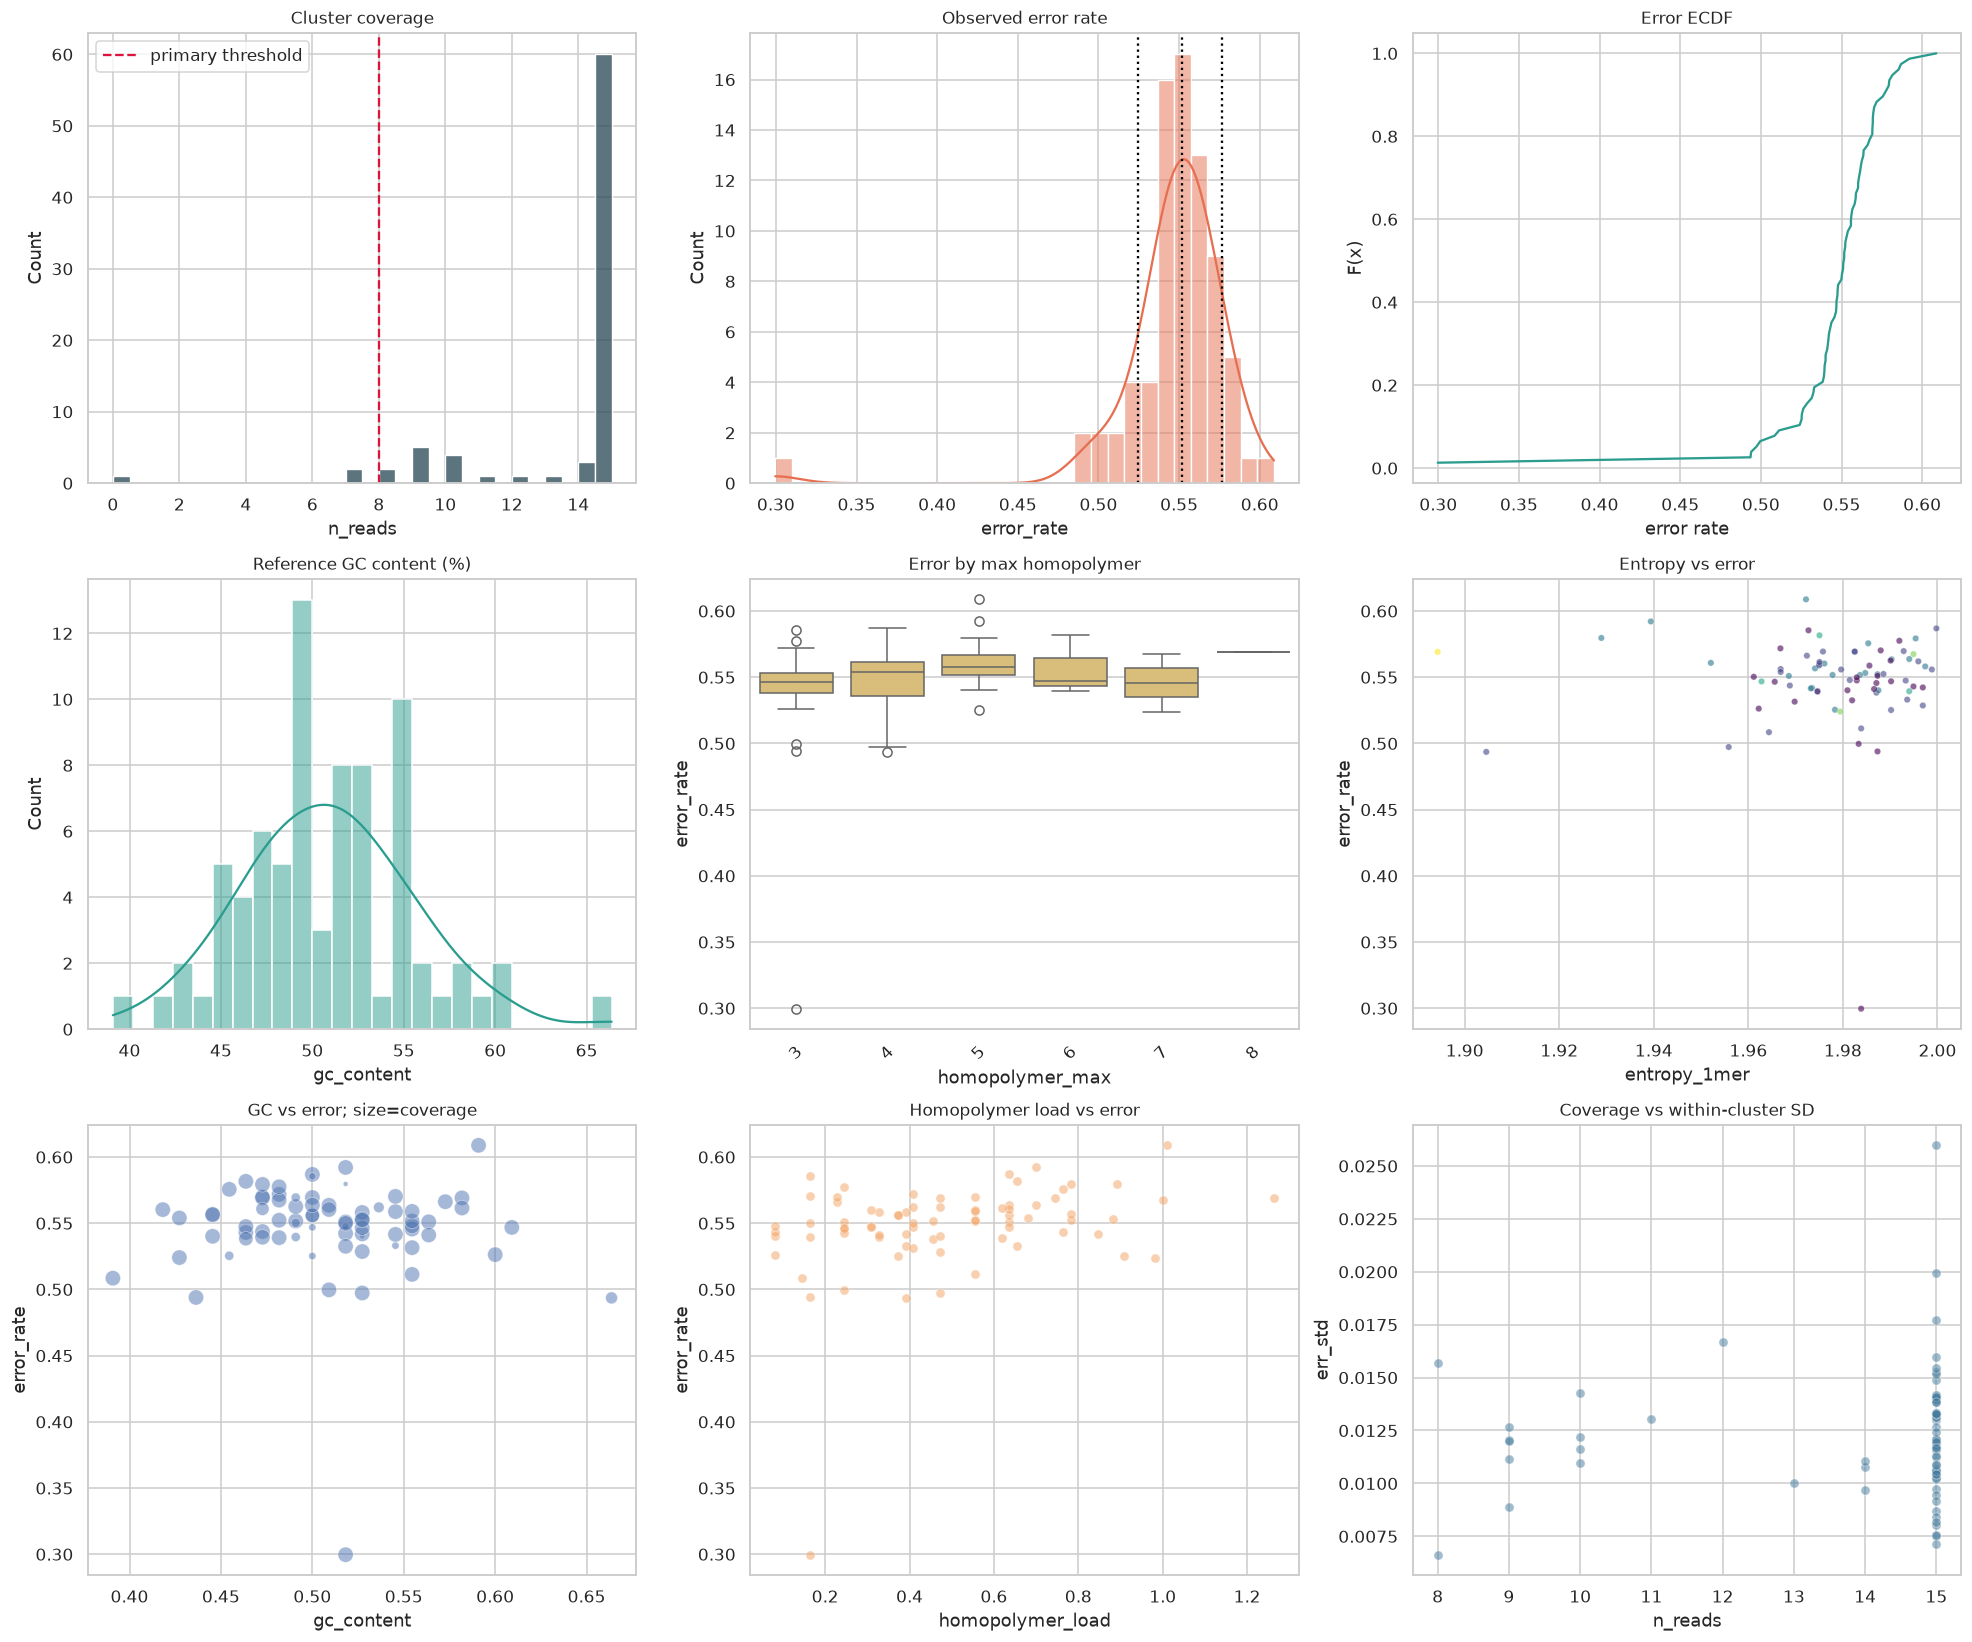

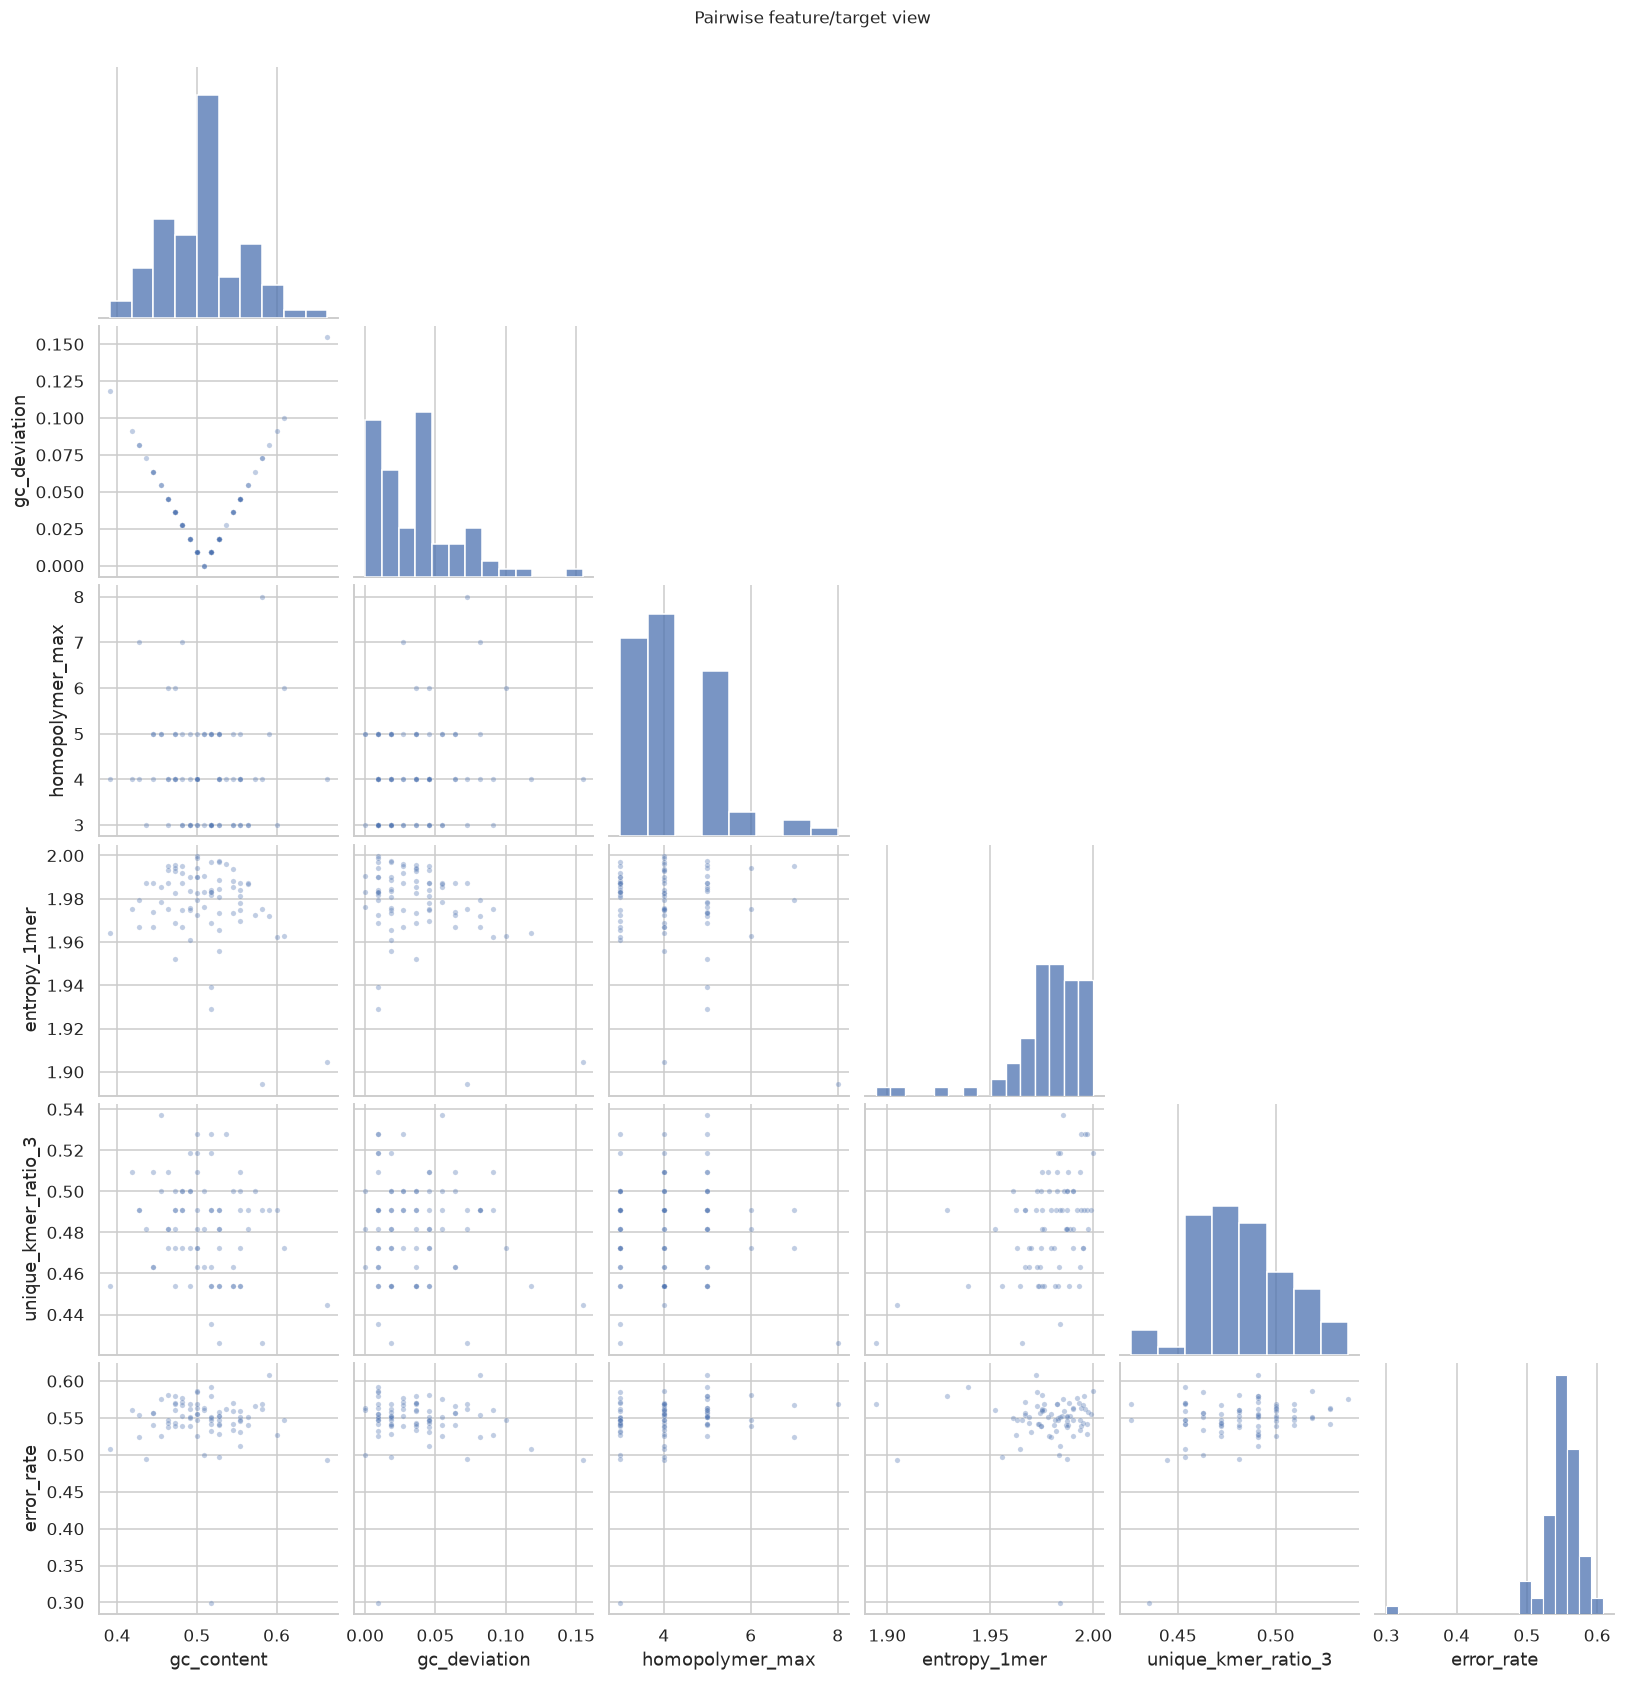

In [ ]:
plot_pd=analysis_pd.copy()
fig,ax=plt.subplots(3,3,figsize=(18,15))
# Coverage distribution.
sns.histplot(feature_pd.n_reads,bins=30,ax=ax[0,0],color='#264653')
ax[0,0].axvline(PRIMARY_MIN_READS,color='crimson',ls='--',label='primary threshold'); ax[0,0].legend(); ax[0,0].set_title('Cluster coverage')
# Error distribution and ECDF.
sns.histplot(plot_pd.error_rate,bins=30,kde=True,ax=ax[0,1],color='#e76f51'); ax[0,1].set_title('Observed error rate')
for q in [0.1,0.5,0.9]: ax[0,1].axvline(plot_pd.error_rate.quantile(q),ls=':',color='black')
xs=np.sort(plot_pd.error_rate); ax[0,2].plot(xs,np.arange(1,len(xs)+1)/len(xs),color='#2a9d8f'); ax[0,2].set_title('Error ECDF'); ax[0,2].set_xlabel('error rate'); ax[0,2].set_ylabel('F(x)')
# Composition and risk.
sns.histplot(plot_pd.gc_content*100,bins=25,kde=True,ax=ax[1,0],color='#2a9d8f'); ax[1,0].set_title('Reference GC content (%)')
sns.boxplot(data=plot_pd,x='homopolymer_max',y='error_rate',ax=ax[1,1],color='#e9c46a'); ax[1,1].set_title('Error by max homopolymer'); ax[1,1].tick_params(axis='x',rotation=45)
sns.scatterplot(data=plot_pd,x='entropy_1mer',y='error_rate',hue='homopolymer_max',palette='viridis',ax=ax[1,2],s=18,alpha=.6,legend=False); ax[1,2].set_title('Entropy vs error')
# Relationships and coverage.
sns.scatterplot(data=plot_pd,x='gc_content',y='error_rate',size='n_reads',sizes=(10,100),alpha=.5,ax=ax[2,0],legend=False); ax[2,0].set_title('GC vs error; size=coverage')
sns.scatterplot(data=plot_pd,x='homopolymer_load',y='error_rate',alpha=.5,ax=ax[2,1],color='#f4a261'); ax[2,1].set_title('Homopolymer load vs error')
sns.scatterplot(data=plot_pd,x='n_reads',y='err_std',alpha=.5,ax=ax[2,2],color='#457b9d'); ax[2,2].set_title('Coverage vs within-cluster SD')
plt.tight_layout(); plt.savefig(PROJECT_ROOT/'outputs/figures/eda_matrix.png',dpi=160,bbox_inches='tight'); plt.show()

# Pairwise feature view on a bounded sample.
pair_cols=['gc_content','gc_deviation','homopolymer_max','entropy_1mer','unique_kmer_ratio_3','error_rate']
sample_pair=plot_pd[pair_cols].sample(min(600,len(plot_pd)),random_state=SEED)
g=sns.pairplot(sample_pair,corner=True,diag_kind='hist',plot_kws={'alpha':.35,'s':12})
g.fig.suptitle('Pairwise feature/target view',y=1.02); g.fig.savefig(PROJECT_ROOT/'outputs/figures/pairplot_features.png',dpi=140,bbox_inches='tight'); plt.show()

## 09. Statistical analysis with multiplicity and uncertainty control

**Why this step is used.** Pearson measures linear association; Spearman measures monotonic association. Mutual information is an exploratory dependence score. Group tests and false-discovery-rate correction are used because dozens of features create multiple-testing risk.

**Alternatives considered.** A parametric Pearson-only analysis would miss monotonic nonlinear relationships and can be distorted by outliers. ANOVA is not assumed because error distributions are skewed and group variances differ; Kruskal–Wallis and Welch-style comparisons are safer first-line diagnostics.

**Architecture view.**

```text
features + target -> Pearson/Spearman/MI -> group tests -> BH-FDR -> bootstrap CIs -> evidence table
```

In [ ]:
from sklearn.feature_selection import mutual_info_regression

FORBIDDEN={'sequence_id','sequence','platform','n_reads','error_rate','err_mean','err_median','err_trim10','err_std','err_q25','err_q75','contam_frac','gc_target_empirical'}
NUMERIC_FOR_STATS=[c for c in analysis_pd.columns if c not in FORBIDDEN and pd.api.types.is_numeric_dtype(analysis_pd[c])]
stat_rows=[]
for c in NUMERIC_FOR_STATS:
    x=analysis_pd[c].astype(float).fillna(analysis_pd[c].median()).values; y=analysis_pd.error_rate.values
    if np.std(x)==0:
        pr=pp=sr=sp=np.nan
    else:
        pr,pp=stats.pearsonr(x,y); sr,sp=stats.spearmanr(x,y)
    stat_rows.append({'feature':c,'pearson_r':pr,'pearson_p':pp,'spearman_r':sr,'spearman_p':sp})
assoc_pd=pd.DataFrame(stat_rows)
mi_input=analysis_pd[NUMERIC_FOR_STATS].astype(float).fillna(analysis_pd[NUMERIC_FOR_STATS].median())
assoc_pd['mutual_information']=mutual_info_regression(mi_input,analysis_pd.error_rate,random_state=SEED)
# Benjamini-Hochberg correction across Pearson and Spearman screens separately.
def bh_adjust(p):
    p=np.nan_to_num(np.asarray(p,dtype=float),nan=1.0); order=np.argsort(p); m=len(p); adj=np.empty(m)
    adj[order]=np.minimum.accumulate((p[order]*m/np.arange(1,m+1))[::-1])[::-1]
    return np.clip(adj,0,1)
assoc_pd['pearson_p_bh']=bh_adjust(assoc_pd.pearson_p); assoc_pd['spearman_p_bh']=bh_adjust(assoc_pd.spearman_p)
assoc_pd['abs_spearman']=assoc_pd.spearman_r.abs()
assoc_pd=assoc_pd.sort_values('abs_spearman',ascending=False)
assoc_pd.to_csv(PROJECT_ROOT/'outputs/tables/associations.csv',index=False)
display(assoc_pd.head(25))

# Kruskal-Wallis for homopolymer groups with at least 10 rows.
groups=[g.error_rate.values for _,g in analysis_pd.groupby('homopolymer_max') if len(g)>=10]
kw=stats.kruskal(*groups) if len(groups)>=2 else (np.nan,np.nan)
print('Kruskal-Wallis homopolymer groups:',kw)

# Bootstrap correlations with fixed seed.
def bootstrap_indices(n,B=N_BOOT):
    return np.random.default_rng(SEED).integers(0,n,size=(B,n))
def bootstrap_ci(values,metric,level=.95):
    idx=bootstrap_indices(len(values[0])); vals=[]
    for b in idx:
        try: vals.append(metric(values[0][b],values[1][b]))
        except Exception: pass
    return float(np.nanpercentile(vals,2.5)),float(np.nanpercentile(vals,97.5))

corr_ci_rows=[]
for c in assoc_pd.head(20).feature:
    x=analysis_pd[c].fillna(analysis_pd[c].median()).astype(float).values; y=analysis_pd.error_rate.values
    lo,hi=bootstrap_ci((x,y),lambda a,b: stats.spearmanr(a,b).statistic)
    corr_ci_rows.append({'feature':c,'spearman_ci_lo':lo,'spearman_ci_hi':hi})
corr_ci_pd=pd.DataFrame(corr_ci_rows); assoc_pd=assoc_pd.merge(corr_ci_pd,on='feature',how='left')
assoc_pd.to_csv(PROJECT_ROOT/'outputs/tables/associations_with_bootstrap_ci.csv',index=False)

,feature,pearson_r,pearson_p,spearman_r,spearman_p,mutual_information,pearson_p_bh,spearman_p_bh,abs_spearman
13,homopolymer_load,0.302145,0.007570,0.317568,0.004888,1.215747e-02,0.068782,0.085287,0.317568
12,homopolymer_bases_ge3,0.304116,0.007167,0.310249,0.006033,8.738606e-02,0.068782,0.085287,0.310249
10,homopolymer_mean,0.343596,0.002217,0.303645,0.007262,1.984673e-02,0.051001,0.085287,0.303645
24,repeat_ratio_3,-0.372340,0.000854,-0.297073,0.008698,0.000000e+00,0.039295,0.085287,0.297073
11,homopolymer_runs_ge3,0.286734,0.011463,0.294720,0.009270,4.106570e-02,0.075328,0.085287,0.294720
9,homopolymer_max,0.227408,0.046701,0.250351,0.028093,6.190856e-02,0.238696,0.215380,0.250351
16,homopolymer_max_G,0.194894,0.089406,0.242494,0.033595,2.413805e-02,0.391349,0.220770,0.242494
15,homopolymer_max_C,0.254153,0.025716,0.217414,0.057514,9.690254e-02,0.147869,0.330707,0.217414
23,unique_kmer_ratio_3,0.295933,0.008972,0.197086,0.085791,1.149746e-01,0.068782,0.394639,0.197086
35,fcgr3_nonzero,0.295933,0.008972,0.197086,0.085791,1.031039e-01,0.068782,0.394639,0.197086


Kruskal-Wallis homopolymer groups: KruskalResult(statistic=np.float64(5.8223548078595115), pvalue=np.float64(0.054411627675258395))


## 10. Leakage guard, feature groups, and shared outer folds

**Why this step is used.** Every model and DSQI weight must be evaluated on rows not used to fit it. The shared folds ensure that models and ablations are compared on identical validation cases.

**Alternatives considered.** A single random split is easy but has high variance. Repeated nested CV is stronger but more expensive. This notebook uses fixed 5-fold out-of-fold evaluation, with inner selection avoided or restricted to training folds, and reports bootstrap intervals over the OOF cases.

**Architecture view.**

```text
sequence-only features -> forbidden-column assertion -> duplicate check -> shared KFold indices
```

In [ ]:
# Remove identifiers and all run-derived variables from model inputs.
FEATURE_COLS=[c for c in analysis_pd.columns if c not in FORBIDDEN and c not in {'err_mean','err_median','err_trim10','err_std','err_q25','err_q75'}]
# Keep only finite numeric design features.
FEATURE_COLS=[c for c in FEATURE_COLS if pd.api.types.is_numeric_dtype(analysis_pd[c])]
X=analysis_pd[FEATURE_COLS].astype(float).replace([np.inf,-np.inf],np.nan).fillna(0.0).values
Y=analysis_pd.error_rate.astype(float).values
assert not (set(FEATURE_COLS)&FORBIDDEN), set(FEATURE_COLS)&FORBIDDEN
assert analysis_pd.sequence.nunique()==len(analysis_pd), 'Duplicate sequences require group-aware splitting.'
FOLDS=list(KFold(N_FOLDS,shuffle=True,random_state=SEED).split(X))
print('Design matrix:',X.shape,'features')
print('Duplicate sequence count:',len(analysis_pd)-analysis_pd.sequence.nunique())
print('Feature groups:',Counter('composition' if c.startswith(('freq_','gc_','at_','purine')) else
                                 'homopolymer' if c.startswith('homopolymer') else
                                 'information' if c.startswith(('entropy','unique','repeat','max_kmer','local_')) else
                                 'fcgr' if c.startswith('fcgr') else 'other' for c in FEATURE_COLS))

Design matrix: (77, 46) features
Duplicate sequence count: 0
Feature groups: Counter({'information': 18, 'fcgr': 10, 'homopolymer': 9, 'composition': 8, 'other': 1})


## 11. Spark MLlib regression demonstration

**Why this step is used.** Spark MLlib is required by the project plan and demonstrates distributed-style feature assembly and model fitting. The final leaderboard below uses shared OOF scikit-learn models because MLlib does not provide a simple, identical nested OOF harness in this Colab implementation.

**Alternatives considered.** Reporting only an MLlib single split would be shorter but would make model comparisons sensitive to one split. MLlib results are labeled as an implementation demonstration; OOF results are the final generalization metrics.

**Architecture view.**

```text
Spark DataFrame -> VectorAssembler -> train/test split -> LinearRegression + RandomForest -> MAE/RMSE/R2
```

In [ ]:
ml_df=clean_df.select('sequence_id','error_rate',*FEATURE_COLS).withColumn('label',F.col('error_rate'))
assembler=VectorAssembler(inputCols=FEATURE_COLS,outputCol='features',handleInvalid='skip')
ml_train,ml_test=ml_df.randomSplit([.8,.2],seed=SEED)
ml_models={'Spark LinearRegression':SparkLinearRegression(featuresCol='features',labelCol='label',maxIter=100,regParam=.01),
           'Spark RandomForest':SparkRandomForestRegressor(featuresCol='features',labelCol='label',numTrees=25,maxDepth=8,seed=SEED)}
ml_rows=[]
for name,est in ml_models.items():
    fit=Pipeline(stages=[assembler,est]).fit(ml_train); pred=fit.transform(ml_test)
    mets={m:RegressionEvaluator(labelCol='label',predictionCol='prediction',metricName=m).evaluate(pred) for m in ['mae','rmse','r2']}
    ml_rows.append({'model':name,**mets}); fit.write().overwrite().save(str(PROJECT_ROOT/'models'/name.replace(' ','_')))
ml_demo_pd=pd.DataFrame(ml_rows); ml_demo_pd.to_csv(PROJECT_ROOT/'outputs/tables/spark_mllib_regression_demo.csv',index=False); display(ml_demo_pd)

26/08/24 08:11:17 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/08/24 08:11:18 WARN Instrumentation: [2d16aed1] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


,model,mae,rmse,r2
0,Spark LinearRegression,0.025970,0.033631,-0.630656
1,Spark RandomForest,0.020869,0.028701,-0.187633


## 12. Out-of-fold regression and metric correctness

**Why this step is used.** Each OOF prediction is made by a model that did not train on that row. This makes MAE, RMSE, R², Pearson, and Spearman comparable across models.

**Metric definitions.**

| Metric | Formula / interpretation |
|---|---|
| MAE | Mean absolute prediction error; same units as the target |
| RMSE | Square root of mean squared error; penalizes large misses |
| R² | \(1-SS_{res}/SS_{tot}\); can be negative out of sample |
| Pearson | Linear association between observed and predicted values |
| Spearman | Rank association; useful for quality ordering |

**Alternatives considered.** Weighted metrics are not used for the headline because coverage weights change the estimand and can flatter models by down-weighting difficult low-coverage sequences. Coverage is reported separately.

**Architecture view.**

```text
shared folds -> fit on fold-train -> predict fold-validation -> concatenate OOF -> metrics + bootstrap CIs
```

In [ ]:
MODELS={
    'Ridge':make_pipeline(StandardScaler(),Ridge(alpha=10.0)),
    'ExtraTrees':ExtraTreesRegressor(n_estimators=35,min_samples_leaf=3,random_state=SEED,n_jobs=-1),
    'RandomForest':RandomForestRegressor(n_estimators=35,min_samples_leaf=3,random_state=SEED,n_jobs=-1),
}
OOF={}; fold_importances=defaultdict(list); fold_permutation=defaultdict(list)
for name,make in MODELS.items():
    oof=np.full(len(Y),np.nan)
    for fold,(tr,va) in enumerate(FOLDS):
        model=make if not callable(make) else make
        # Every entry is an estimator instance; clone via sklearn clone for fold independence.
        from sklearn.base import clone
        m=clone(model); m.fit(X[tr],Y[tr]); oof[va]=m.predict(X[va])
        if name in ['RandomForest','ExtraTrees']:
            fold_importances[name].append(np.asarray(m.feature_importances_))
    OOF[name]=oof

# Add a transparent mean-target baseline and a GC-only baseline.
OOF['Mean baseline']=np.full(len(Y),Y[FOLDS[0][0]].mean())
gc_idx=FEATURE_COLS.index('gc_content') if 'gc_content' in FEATURE_COLS else 0
gc_model=make_pipeline(StandardScaler(),Ridge(alpha=10.0)); oof_gc=np.full(len(Y),np.nan)
for tr,va in FOLDS:
    m=clone(gc_model); m.fit(X[tr][:,[gc_idx]],Y[tr]); oof_gc[va]=m.predict(X[va][:,[gc_idx]])
OOF['GC-only Ridge']=oof_gc
print('OOF predictions created:',list(OOF))

OOF predictions created: ['Ridge', 'ExtraTrees', 'RandomForest', 'Mean baseline', 'GC-only Ridge']


,MAE,RMSE,R2,Pearson,Spearman,model,R2_lo,R2_hi,Spearman_lo,Spearman_hi
3,0.019481,0.035947,-0.006638,NaN,NaN,Mean baseline,-0.069228,-0.000146,NaN,NaN
4,0.020687,0.037163,-0.075855,-0.348390,-0.246697,GC-only Ridge,-0.257554,-0.041259,-0.425591,-0.026845
1,0.022796,0.038084,-0.129866,-0.029426,0.025606,ExtraTrees,-0.638246,-0.051685,-0.171905,0.299290
2,0.022408,0.038151,-0.133806,-0.043530,0.007755,RandomForest,-0.667984,-0.042131,-0.240687,0.243601
0,0.026105,0.040881,-0.301878,0.095777,0.145880,Ridge,-1.725914,-0.046493,-0.086223,0.355479


,model,delta_R2_vs_GC,delta_R2_lo,delta_R2_hi
0,Ridge,-0.433695,-1.561305,0.013308
1,ExtraTrees,-0.083494,-0.419437,0.110811
2,RandomForest,-0.105499,-0.492051,0.045864
3,Mean baseline,0.101864,0.023138,0.245975
4,GC-only Ridge,0.000000,0.000000,0.000000


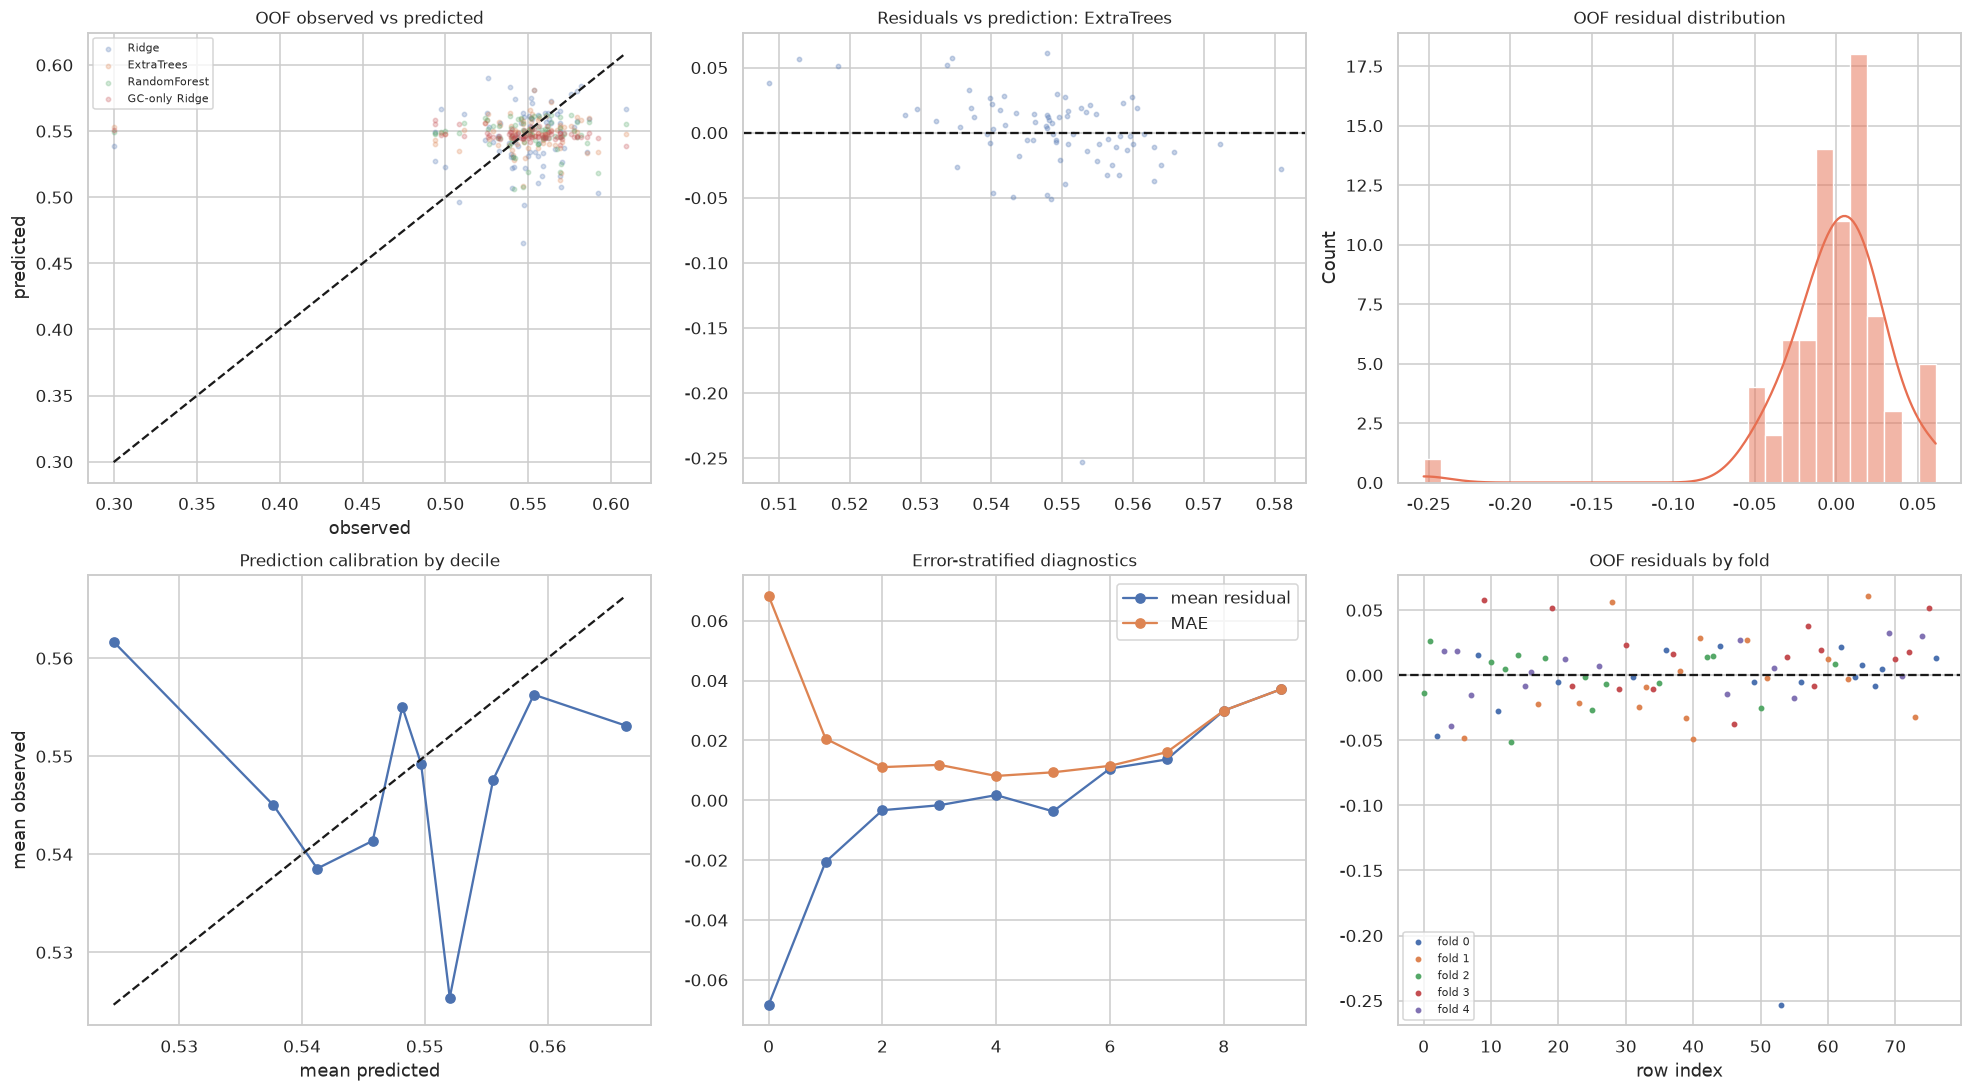

In [ ]:
def regression_metrics(y,p):
    return {'MAE':mean_absolute_error(y,p),'RMSE':mean_squared_error(y,p)**.5,'R2':r2_score(y,p),
            'Pearson':stats.pearsonr(y,p).statistic,'Spearman':stats.spearmanr(y,p).statistic}

def paired_bootstrap_metric(y,p1,p2=None,metric='R2',B=N_BOOT):
    rng=np.random.default_rng(SEED); out=[]
    for _ in range(B):
        idx=rng.integers(0,len(y),len(y))
        if p2 is None: out.append(regression_metrics(y[idx],p1[idx])[metric])
        else: out.append(regression_metrics(y[idx],p1[idx])[metric]-regression_metrics(y[idx],p2[idx])[metric])
    return np.asarray(out)

reg_rows=[]; boot_distributions={}
for name,p in OOF.items():
    m=regression_metrics(Y,p); b=paired_bootstrap_metric(Y,p,metric='R2'); bs=paired_bootstrap_metric(Y,p,metric='Spearman')
    boot_distributions[name]={'R2':b,'Spearman':bs}
    m.update({'model':name,'R2_lo':np.percentile(b,2.5),'R2_hi':np.percentile(b,97.5),
              'Spearman_lo':np.percentile(bs,2.5),'Spearman_hi':np.percentile(bs,97.5)})
    reg_rows.append(m)
reg_results=pd.DataFrame(reg_rows).sort_values('RMSE'); reg_results.to_csv(PROJECT_ROOT/'outputs/tables/oof_regression_results.csv',index=False)
display(reg_results)

# Paired bootstrap against the GC-only baseline: the comparison uses the same resampled cases.
base=OOF['GC-only Ridge']; ablation_rows=[]
for name,p in OOF.items():
    d=paired_bootstrap_metric(Y,p,base,metric='R2')
    ablation_rows.append({'model':name,'delta_R2_vs_GC':d.mean(),'delta_R2_lo':np.percentile(d,2.5),'delta_R2_hi':np.percentile(d,97.5)})
ablation_vs_gc=pd.DataFrame(ablation_rows); ablation_vs_gc.to_csv(PROJECT_ROOT/'outputs/tables/oof_paired_model_comparisons.csv',index=False); display(ablation_vs_gc)

# Prediction/residual diagnostics for the strongest non-baseline model by RMSE.
best_model=reg_results[~reg_results.model.isin(['Mean baseline','GC-only Ridge'])].iloc[0].model
best_pred=OOF[best_model]; residual=Y-best_pred
fig,ax=plt.subplots(2,3,figsize=(18,10))
for name,p in OOF.items():
    if name!='Mean baseline': ax[0,0].scatter(Y,p,s=8,alpha=.25,label=name)
lo,hi=min(Y.min(),best_pred.min()),max(Y.max(),best_pred.max()); ax[0,0].plot([lo,hi],[lo,hi],'k--'); ax[0,0].set_title('OOF observed vs predicted'); ax[0,0].set_xlabel('observed'); ax[0,0].set_ylabel('predicted'); ax[0,0].legend(fontsize=7)
ax[0,1].scatter(best_pred,residual,s=8,alpha=.3); ax[0,1].axhline(0,color='k',ls='--'); ax[0,1].set_title(f'Residuals vs prediction: {best_model}')
sns.histplot(residual,bins=30,kde=True,ax=ax[0,2],color='#e76f51'); ax[0,2].set_title('OOF residual distribution')
cal=pd.DataFrame({'y':Y,'pred':best_pred}); cal['decile']=pd.qcut(cal.pred,10,duplicates='drop'); cg=cal.groupby('decile',observed=False).agg(y=('y','mean'),pred=('pred','mean')).reset_index(); ax[1,0].plot(cg.pred,cg.y,'o-'); ax[1,0].plot([cg.pred.min(),cg.pred.max()],[cg.pred.min(),cg.pred.max()],'k--'); ax[1,0].set_title('Prediction calibration by decile'); ax[1,0].set_xlabel('mean predicted'); ax[1,0].set_ylabel('mean observed')
errbin=pd.qcut(Y,10,duplicates='drop'); rb=pd.DataFrame({'y':Y,'resid':residual}).groupby(errbin,observed=False).agg(mean_resid=('resid','mean'),mae=('resid',lambda z:np.mean(abs(z)))).reset_index(); ax[1,1].plot(range(len(rb)),rb.mean_resid,'o-',label='mean residual'); ax[1,1].plot(range(len(rb)),rb.mae,'o-',label='MAE'); ax[1,1].legend(); ax[1,1].set_title('Error-stratified diagnostics')
for fold,(tr,va) in enumerate(FOLDS): ax[1,2].scatter(va,residual[va],s=8,label=f'fold {fold}')
ax[1,2].axhline(0,color='k',ls='--'); ax[1,2].set_title('OOF residuals by fold'); ax[1,2].set_xlabel('row index'); ax[1,2].legend(fontsize=7)
plt.tight_layout(); plt.savefig(PROJECT_ROOT/'outputs/figures/regression_diagnostics.png',dpi=160,bbox_inches='tight'); plt.show()

## 13. Classification with fold-safe risk labels

**Why this step is used.** Risk classes make the index operational for screening. Class thresholds are estimated from each training fold and then applied to its validation fold; the validation labels are never used to define their own boundaries.

**Alternatives considered.** Fixed literature thresholds would be preferable if an agreed domain standard existed. For this benchmark-specific project, empirical training-fold tertiles are more transparent than arbitrary values. Accuracy is not reported alone; macro-F1, balanced accuracy, per-class metrics, ROC-AUC, PR-AUC, and confusion matrices are included.

**Architecture view.**

```text
outer fold -> training tertiles of error -> train classifier -> validation probabilities
                                                   |
                                                   +-> macro metrics + ROC/PR + confusion matrix
```

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_F1,macro_ROC_AUC,macro_PR_AUC
0,LogisticRegression,0.441558,0.442051,0.445699,0.442051,0.439959,0.571885,0.430005
1,RandomForestClassifier,0.350649,0.351282,0.349725,0.351282,0.349414,0.543690,0.396156


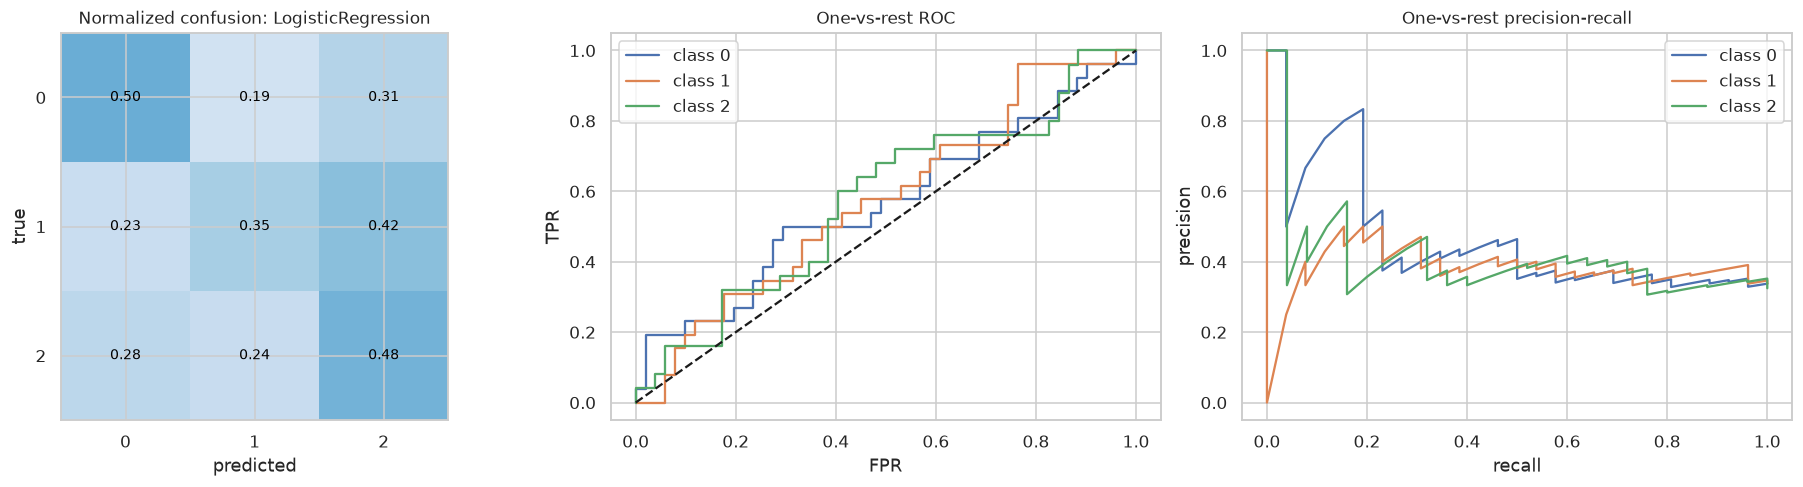

Per-class report:
              precision    recall  f1-score   support

   low error       0.50      0.50      0.50        26
medium error       0.45      0.35      0.39        26
  high error       0.39      0.48      0.43        25

    accuracy                           0.44        77
   macro avg       0.45      0.44      0.44        77
weighted avg       0.45      0.44      0.44        77



In [ ]:
CLS_MODELS={
    'LogisticRegression':make_pipeline(StandardScaler(),LogisticRegression(max_iter=500,class_weight='balanced',random_state=SEED)),
    'RandomForestClassifier':RandomForestClassifier(n_estimators=35,min_samples_leaf=3,class_weight='balanced',random_state=SEED,n_jobs=-1)
}
cls_outputs={}
for name,base_model in CLS_MODELS.items():
    pred=np.full(len(Y),-1,dtype=int); prob=np.full((len(Y),3),np.nan); true=np.full(len(Y),-1,dtype=int); thresholds=[]
    for tr,va in FOLDS:
        q1,q2=np.quantile(Y[tr],[1/3,2/3]); thresholds.append((q1,q2))
        ytr=np.digitize(Y[tr],[q1,q2]); yva=np.digitize(Y[va],[q1,q2]); true[va]=yva
        from sklearn.base import clone
        m=clone(base_model); m.fit(X[tr],ytr); pred[va]=m.predict(X[va]);
        if hasattr(m,'predict_proba'):
            raw_prob=m.predict_proba(X[va])
            prob[va]=0.0
            for jj,cc in enumerate(getattr(m,'classes_',range(raw_prob.shape[1]))): prob[va,int(cc)]=raw_prob[:,jj]
        else: prob[va]=np.eye(3)[pred[va]]
    cls_outputs[name]={'true':true,'pred':pred,'prob':prob,'thresholds':thresholds}

cls_rows=[]
for name,o in cls_outputs.items():
    prec,rec,f1,supp=precision_recall_fscore_support(o['true'],o['pred'],labels=[0,1,2],zero_division=0)
    auc=roc_auc_score(o['true'],o['prob'],multi_class='ovr',average='macro')
    ap=np.mean([average_precision_score((o['true']==k).astype(int),o['prob'][:,k]) for k in range(3)])
    cls_rows.append({'model':name,'accuracy':accuracy_score(o['true'],o['pred']),'balanced_accuracy':balanced_accuracy_score(o['true'],o['pred']),
                     'macro_precision':prec.mean(),'macro_recall':rec.mean(),'macro_F1':f1.mean(),'macro_ROC_AUC':auc,'macro_PR_AUC':ap})
cls_results=pd.DataFrame(cls_rows).sort_values('macro_F1',ascending=False); cls_results.to_csv(PROJECT_ROOT/'outputs/tables/oof_classification_results.csv',index=False); display(cls_results)

best_cls=cls_results.iloc[0].model; o=cls_outputs[best_cls]; cm=confusion_matrix(o['true'],o['pred'],labels=[0,1,2],normalize='true')
fig,ax=plt.subplots(1,3,figsize=(17,4.5))
ax[0].imshow(cm,cmap='Blues',vmin=0,vmax=1); ax[0].set_xticks(range(3)); ax[0].set_yticks(range(3)); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('true'); ax[0].set_title(f'Normalized confusion: {best_cls}')
for i in range(3):
    for j in range(3): ax[0].text(j,i,f'{cm[i,j]:.2f}',ha='center',va='center',color='white' if cm[i,j]>.5 else 'black')
for k in range(3):
    fpr,tpr,_=roc_curve((o['true']==k).astype(int),o['prob'][:,k]); ax[1].plot(fpr,tpr,label=f'class {k}')
ax[1].plot([0,1],[0,1],'k--'); ax[1].set_title('One-vs-rest ROC'); ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].legend()
for k in range(3):
    pr,re,_=precision_recall_curve((o['true']==k).astype(int),o['prob'][:,k]); ax[2].plot(re,pr,label=f'class {k}')
ax[2].set_title('One-vs-rest precision-recall'); ax[2].set_xlabel('recall'); ax[2].set_ylabel('precision'); ax[2].legend()
plt.tight_layout(); plt.savefig(PROJECT_ROOT/'outputs/figures/classification_diagnostics.png',dpi=160,bbox_inches='tight'); plt.show()
print('Per-class report:')
from sklearn.metrics import classification_report
print(classification_report(o['true'],o['pred'],labels=[0,1,2],target_names=['low error','medium error','high error'],zero_division=0))

## 14. Unsupervised clustering and high-dimensional structure

**Why this step is used.** Clustering asks whether sequence-only feature profiles form interpretable reliability groups without using the error target during fitting. PCA/t-SNE/UMAP are visualization tools, not predictive evidence.

**Alternatives considered.** t-SNE can create visually convincing islands from continuous data and is therefore not used as a formal cluster test. Silhouette score and cluster summaries provide quantitative checks; PCA is retained for a stable global projection, while UMAP/t-SNE are optional exploratory views.

**Architecture view.**

```text
sequence-only X -> standardize -> KMeans(k) -> silhouette + cluster summaries
                              \-> PCA / optional UMAP -> visual exploration only
```

Best k: 2


,k,silhouette
0,2,0.190868
1,3,0.122570
2,4,0.109178
3,5,0.100821
4,6,0.099953


,cluster,n,mean_error,mean_gc,mean_hp,mean_entropy
0,0,53,0.544823,0.494854,3.981132,1.983787
1,1,24,0.553111,0.539015,4.541667,1.964824


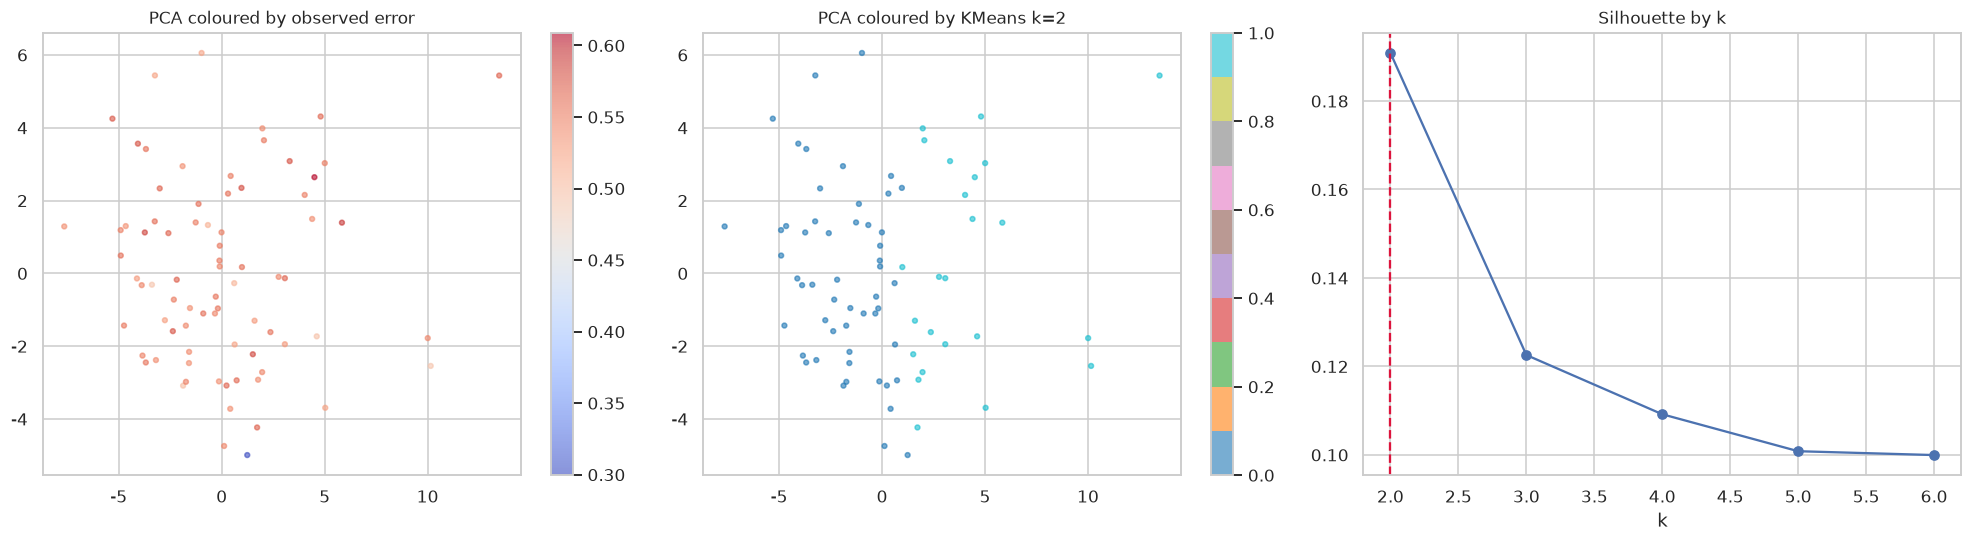

Optional UMAP unavailable: No module named 'umap'


In [ ]:
Xs=StandardScaler().fit_transform(X)
cluster_rows=[]; cluster_preds={}
for k in range(2,7):
    km=SKKMeans(n_clusters=k,n_init=20,random_state=SEED).fit(Xs); lab=km.labels_
    score=silhouette_score(Xs,lab)
    cluster_rows.append({'k':k,'silhouette':score}); cluster_preds[k]=lab
cluster_eval=pd.DataFrame(cluster_rows); best_k=int(cluster_eval.loc[cluster_eval.silhouette.idxmax(),'k']); labels=cluster_preds[best_k]
cluster_summary=analysis_pd.assign(cluster=labels).groupby('cluster').agg(n=('sequence_id','size'),mean_error=('error_rate','mean'),mean_gc=('gc_content','mean'),mean_hp=('homopolymer_max','mean'),mean_entropy=('entropy_1mer','mean')).reset_index()
cluster_eval.to_csv(PROJECT_ROOT/'outputs/tables/clustering_silhouette.csv',index=False); cluster_summary.to_csv(PROJECT_ROOT/'outputs/tables/cluster_summary.csv',index=False)
print('Best k:',best_k); display(cluster_eval); display(cluster_summary)

pca=PCA(n_components=2,random_state=SEED).fit_transform(Xs)
fig,ax=plt.subplots(1,3,figsize=(18,5))
s=ax[0].scatter(pca[:,0],pca[:,1],c=Y,cmap='coolwarm',s=10,alpha=.6); ax[0].set_title('PCA coloured by observed error'); plt.colorbar(s,ax=ax[0])
s=ax[1].scatter(pca[:,0],pca[:,1],c=labels,cmap='tab10',s=10,alpha=.6); ax[1].set_title(f'PCA coloured by KMeans k={best_k}'); plt.colorbar(s,ax=ax[1])
ax[2].plot(cluster_eval.k,cluster_eval.silhouette,'o-'); ax[2].axvline(best_k,ls='--',color='crimson'); ax[2].set_title('Silhouette by k'); ax[2].set_xlabel('k')
plt.tight_layout(); plt.savefig(PROJECT_ROOT/'outputs/figures/clustering_structure.png',dpi=160,bbox_inches='tight'); plt.show()

# Optional nonlinear projection; never used as a metric.
try:
    import umap
    nsub=min(1200,len(Xs)); ids=np.random.default_rng(SEED).choice(len(Xs),nsub,replace=False)
    emb=umap.UMAP(n_neighbors=25,min_dist=.1,random_state=SEED).fit_transform(Xs[ids])
    fig,ax=plt.subplots(1,2,figsize=(12,5)); a=ax[0].scatter(emb[:,0],emb[:,1],c=Y[ids],cmap='coolwarm',s=8); ax[0].set_title('UMAP coloured by error'); plt.colorbar(a,ax=ax[0]); ax[1].scatter(emb[:,0],emb[:,1],c=labels[ids],cmap='tab10',s=8); ax[1].set_title('UMAP coloured by cluster'); plt.tight_layout(); plt.savefig(PROJECT_ROOT/'outputs/figures/umap_structure.png',dpi=150,bbox_inches='tight'); plt.show()
except Exception as e:
    print('Optional UMAP unavailable:',e)

## 15. Fold-wise feature importance and explainability

**Why this step is used.** Global importance calculated on all rows can be optimistic and unstable. The notebook averages Random Forest importance across outer training folds and computes permutation importance on the corresponding held-out folds.

**Alternatives considered.** SHAP is useful for local explanations but can be version-sensitive and expensive for high-dimensional correlated features. Permutation importance is model-agnostic and is therefore the default global comparison. SHAP is attempted only as an optional diagnostic after the leakage-safe model evaluation.

**Architecture view.**

```text
outer fold -> train RF -> held-out permutation -> fold importance -> mean + SD -> feature-family summary
```

,feature,rf_mean,rf_sd,perm_mean,perm_sd
36,local_gc_std,0.179563,0.072672,-0.028591,0.137906
32,local_entropy_mean,0.078960,0.041644,-0.016964,0.081915
35,local_gc_min,0.073183,0.028157,-0.030859,0.064161
29,homopolymer_mean,0.055526,0.023910,-0.001252,0.047808
2,entropy_2mer,0.040730,0.015516,-0.027425,0.048466
6,fcgr3_entropy,0.035660,0.042543,0.066274,0.124253
17,freq_G,0.033894,0.020287,-0.022917,0.070735
8,fcgr3_nonzero,0.033471,0.018292,-0.019658,0.079391
23,homopolymer_load,0.030549,0.020582,0.011977,0.022931
33,local_entropy_std,0.028991,0.005904,-0.019553,0.052412


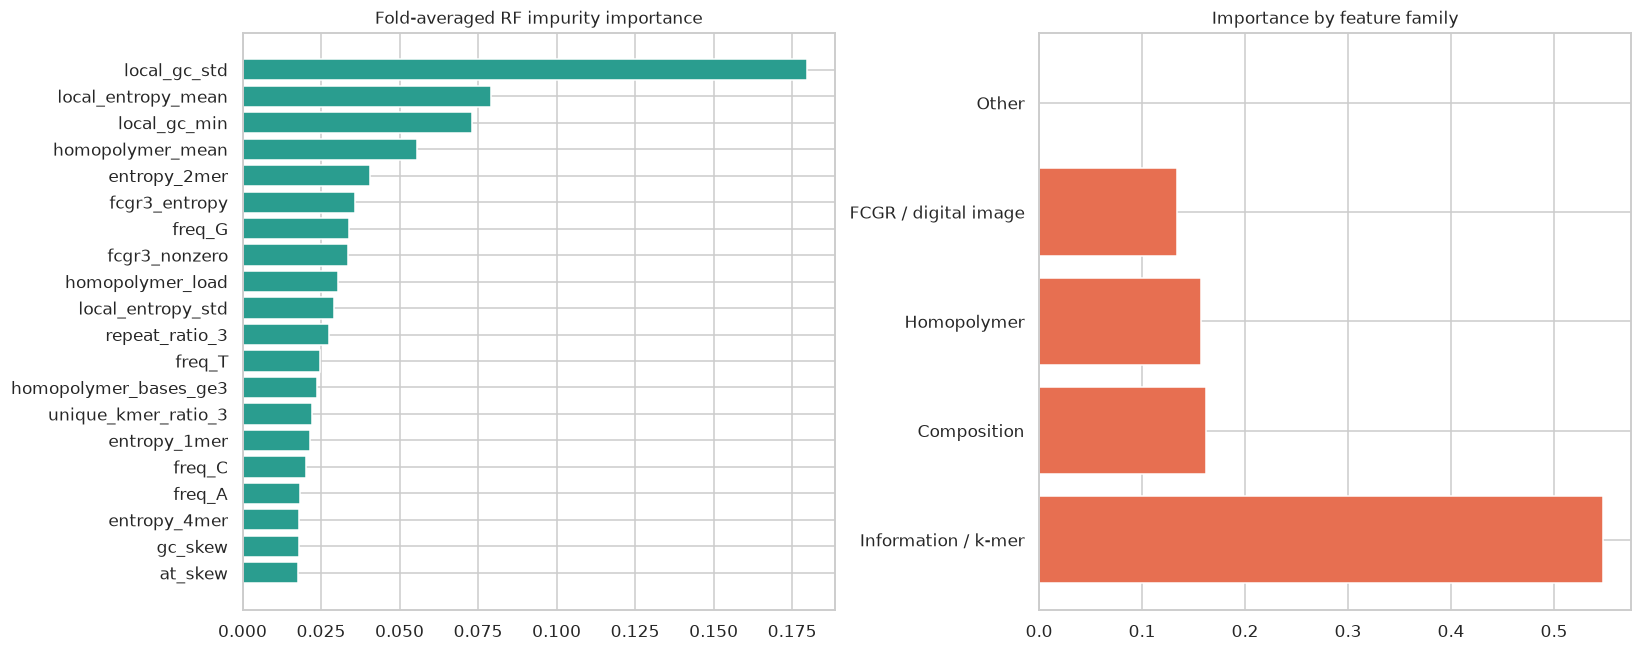

In [ ]:
from sklearn.inspection import permutation_importance
imp_rows=[]
# Fold-wise RF importance.
for arr in fold_importances.get('RandomForest',[]):
    for f,v in zip(FEATURE_COLS,arr): imp_rows.append({'feature':f,'method':'RF impurity','value':float(v)})
# Fold-wise held-out permutation importance, reported as R2 decrease.
perm_rows=[]
for tr,va in FOLDS:
    m=RandomForestRegressor(n_estimators=25,min_samples_leaf=3,random_state=SEED,n_jobs=-1).fit(X[tr],Y[tr])
    pi=permutation_importance(m,X[va],Y[va],n_repeats=PERM_REPEATS,random_state=SEED,scoring='r2',n_jobs=-1)
    for f,mean,std in zip(FEATURE_COLS,pi.importances_mean,pi.importances_std): perm_rows.append({'feature':f,'method':'held-out permutation R2 decrease','value':float(mean),'sd':float(std)})
imp_pd=pd.DataFrame(imp_rows).groupby('feature').agg(rf_mean=('value','mean'),rf_sd=('value','std')).reset_index()
perm_pd=pd.DataFrame(perm_rows).groupby('feature').agg(perm_mean=('value','mean'),perm_sd=('value','std')).reset_index()
importance_pd=imp_pd.merge(perm_pd,on='feature',how='outer').fillna(0).sort_values('rf_mean',ascending=False)
importance_pd.to_csv(PROJECT_ROOT/'outputs/tables/foldwise_feature_importance.csv',index=False)
display(importance_pd.head(30))

def group_name(c):
    if c.startswith('homopolymer'):return 'Homopolymer'
    if c.startswith(('fcgr',)):return 'FCGR / digital image'
    if c.startswith(('entropy','unique','repeat','max_kmer','local_')):return 'Information / k-mer'
    if c.startswith(('freq_','gc_','at_')):return 'Composition'
    return 'Other'
importance_pd['group']=importance_pd.feature.map(group_name)
group_imp=importance_pd.groupby('group').agg(rf_mean=('rf_mean','sum'),perm_mean=('perm_mean','sum')).sort_values('rf_mean',ascending=False)
fig,ax=plt.subplots(1,2,figsize=(15,6)); top=importance_pd.head(20).sort_values('rf_mean'); ax[0].barh(top.feature,top.rf_mean,color='#2a9d8f'); ax[0].set_title('Fold-averaged RF impurity importance'); ax[1].barh(group_imp.index,group_imp.rf_mean,color='#e76f51'); ax[1].set_title('Importance by feature family'); plt.tight_layout(); plt.savefig(PROJECT_ROOT/'outputs/figures/feature_importance.png',dpi=160,bbox_inches='tight'); plt.show()

## 16. Similarity graph analytics

**Why this step is used.** The graph asks whether similar reference sequences form connected components with different observed error rates. This is a descriptive structural analysis, not a substitute for a held-out predictive model.

**Alternatives considered.** Full all-vs-all similarity is \(O(n^2)\), which is inappropriate for 10,000 sequences in Colab. A bounded sample and top-k edges preserve a tractable, reproducible demonstration. GraphX is a Scala Spark API; an equivalent GraphX translation is included in the explanatory cell below, while NetworkX executes the Python analysis.

**Architecture view.**

```text
sampled reference sequences -> pairwise similarity on bounded sample -> top-k graph
                                                        |
                         degree + connected components + PageRank + threshold sensitivity
```

Graph nodes: 60 edges: 0 components: 60


,component,n,mean_error,mean_degree
9,9,1,0.592107,0.0
48,48,1,0.586854,0.0
30,30,1,0.581608,0.0
5,5,1,0.579633,0.0
47,47,1,0.577501,0.0
36,36,1,0.571767,0.0
41,41,1,0.570239,0.0
19,19,1,0.569718,0.0
43,43,1,0.569414,0.0
8,8,1,0.569122,0.0


,threshold,edges,components,largest_component
0,0.70,1,59,2
1,0.75,0,60,1
2,0.80,0,60,1
3,0.85,0,60,1
4,0.90,0,60,1


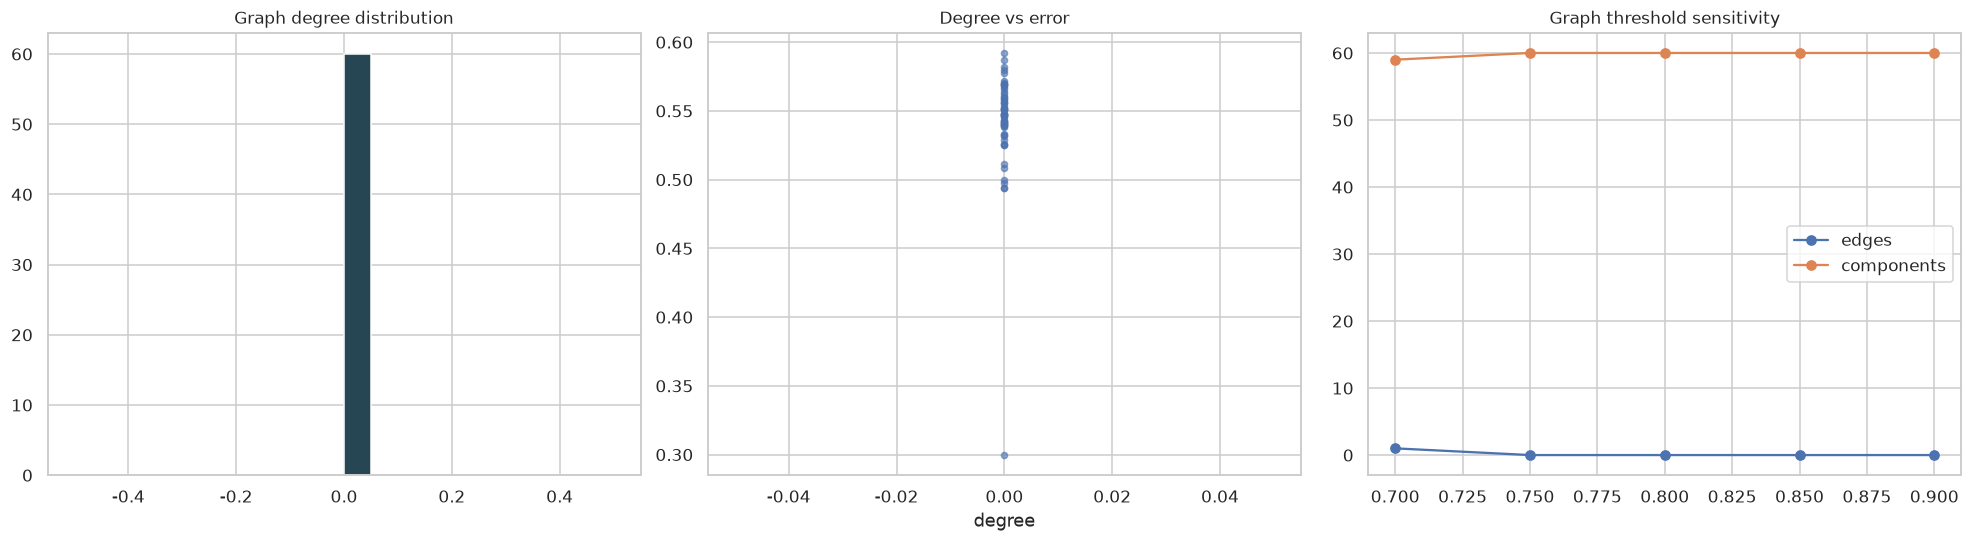

In [ ]:
if nx is not None:
    gdf=analysis_pd[['sequence_id','sequence','error_rate']].head(min(GRAPH_N,len(analysis_pd))).copy()
    G=nx.Graph(); G.add_nodes_from([(r.sequence_id,{'error_rate':float(r.error_rate)}) for r in gdf.itertuples()])
    def sim(a,b):
        return 1.0-norm_lev(a,b)
    TOP_K=5; THRESHOLDS=[.70,.75,.80,.85,.90]
    pair_cache={}
    for i,r1 in gdf.iterrows():
        vals=[]
        for j,r2 in gdf.iterrows():
            if i>=j: continue
            s=sim(r1.sequence,r2.sequence); pair_cache[(r1.sequence_id,r2.sequence_id)]=s; vals.append((s,r2.sequence_id))
        for s,other in sorted(vals,reverse=True)[:TOP_K]:
            if s>=.80: G.add_edge(r1.sequence_id,other,weight=float(s))
    deg=dict(G.degree()); pr=nx.pagerank(G,weight='weight') if G.number_of_edges() else {n:1/G.number_of_nodes() for n in G.nodes()}
    comp={n:i for i,c in enumerate(nx.connected_components(G)) for n in c}
    graph_metrics=pd.DataFrame([{'sequence_id':n,'degree':deg[n],'pagerank':pr[n],'component':comp[n],'error_rate':G.nodes[n]['error_rate']} for n in G.nodes()])
    graph_comp=graph_metrics.groupby('component').agg(n=('sequence_id','size'),mean_error=('error_rate','mean'),mean_degree=('degree','mean')).reset_index()
    graph_metrics.to_csv(PROJECT_ROOT/'outputs/tables/graph_metrics.csv',index=False); graph_comp.to_csv(PROJECT_ROOT/'outputs/tables/graph_components.csv',index=False)
    print('Graph nodes:',G.number_of_nodes(),'edges:',G.number_of_edges(),'components:',nx.number_connected_components(G)); display(graph_comp.sort_values('mean_error',ascending=False).head(15))
    sens=[]
    for th in THRESHOLDS:
        H=nx.Graph(); H.add_nodes_from(G.nodes())
        for (a,b),s in pair_cache.items():
            if s>=th:H.add_edge(a,b,weight=s)
        comps=list(nx.connected_components(H)); sens.append({'threshold':th,'edges':H.number_of_edges(),'components':len(comps),'largest_component':max(map(len,comps)) if comps else 0})
    graph_sensitivity=pd.DataFrame(sens); graph_sensitivity.to_csv(PROJECT_ROOT/'outputs/tables/graph_threshold_sensitivity.csv',index=False); display(graph_sensitivity)
    fig,ax=plt.subplots(1,3,figsize=(18,5)); ax[0].hist(graph_metrics.degree,bins=20,color='#264653'); ax[0].set_title('Graph degree distribution'); ax[1].scatter(graph_metrics.degree,graph_metrics.error_rate,s=16,alpha=.6); ax[1].set_title('Degree vs error'); ax[1].set_xlabel('degree'); ax[2].plot(graph_sensitivity.threshold,graph_sensitivity.edges,'o-',label='edges'); ax[2].plot(graph_sensitivity.threshold,graph_sensitivity.components,'o-',label='components'); ax[2].legend(); ax[2].set_title('Graph threshold sensitivity'); plt.tight_layout(); plt.savefig(PROJECT_ROOT/'outputs/figures/graph_diagnostics.png',dpi=160,bbox_inches='tight'); plt.show()
else:
    print('NetworkX unavailable; graph section skipped.')

### GraphX compatibility view

```scala
// Equivalent GraphX semantics for a Scala-enabled Spark runtime.
case class VertexAttr(sequenceId: String, errorRate: Double)
case class EdgeAttr(similarity: Double)
val graph = Graph(vertices, edges)
val degree = graph.degrees
val components = graph.connectedComponents().vertices
val pageRank = graph.pageRank(0.0001).vertices
```

NetworkX is used here because the primary notebook kernel is Python. The graph definition, edge meaning, and requested algorithms are the same; the notebook does not claim that Python NetworkX is GraphX.

## 17. Fold-safe DSQI construction

**Why this step is used.** DSQI is a fitted scoring function, not merely a post-hoc chart. The score is defined as:

\[
 DSQI(S) = 100\left(1-\sum_j w_j P_j(S)\right), \quad P_j\in[0,1],\quad \sum_j w_j=1,
\]

where larger `P` means larger design penalty. Quality is higher when DSQI is higher.

**Weighting strategies.** Equal weights are a transparent baseline. Statistical weights use training-fold absolute Spearman association with error. Model-derived weights use training-fold Random Forest importance mapped to interpretable component families. All OOF DSQI values use weights fit on the corresponding training fold.

**Alternatives considered.** A hand-picked DSQI would be easier to explain but would not be evidence-first. NNLS is used for the fitted analytical score because it enforces non-negative, sum-normalized penalty weights; plain unconstrained OLS could produce semantically incoherent negative penalties.

**Architecture view.**

```text
sequence features -> train-fold normalization -> quality components -> penalties
                                                     |
                equal / statistical / model-derived weights (train fold only)
                                                     v
                                      OOF DSQI 0–100 -> validation
```

In [ ]:
COMPONENTS=['gc_quality','homopolymer_quality','entropy_quality','kmer_quality','length_quality']
COMP_FEATURES={'gc_quality':['gc_deviation'],'homopolymer_quality':['homopolymer_max'],
               'entropy_quality':['entropy_1mer'],'kmer_quality':['unique_kmer_ratio_3'],'length_quality':['length']}

def quality_matrix(train_idx,apply_idx):
    tr=analysis_pd.iloc[train_idx]; ap=analysis_pd.iloc[apply_idx]
    def q_high(v,lo,hi): return np.clip((v-lo)/max(hi-lo,1e-9),0,1)
    # Reference values are calculated only on the training fold.
    gc_med=tr.gc_content.median(); gc_scale=max((tr.gc_content-gc_med).abs().quantile(.90),.01)
    gcq=np.exp(-abs(ap.gc_content.values-gc_med)/gc_scale)
    hp_lo,hp_hi=tr.homopolymer_max.quantile(.10),tr.homopolymer_max.quantile(.90)
    hpq=1-q_high(ap.homopolymer_max.values,hp_lo,hp_hi)
    enq=q_high(ap.entropy_1mer.values,tr.entropy_1mer.quantile(.10),tr.entropy_1mer.quantile(.90))
    kmq=q_high(ap.unique_kmer_ratio_3.values,tr.unique_kmer_ratio_3.quantile(.10),tr.unique_kmer_ratio_3.quantile(.90))
    med_len=tr.length.median(); span=max(tr.length.quantile(.90)-tr.length.quantile(.10),1)
    lq=np.clip(1-abs(ap.length.values-med_len)/span,0,1)
    return np.column_stack([gcq,hpq,enq,kmq,lq]).astype(float)

def fit_weight_sets(Qtr,ytr,rf_component=None):
    P=1-Qtr; yn=(ytr-ytr.min())/max(ytr.max()-ytr.min(),1e-9)
    equal=np.ones(P.shape[1])/P.shape[1]
    raw=[]
    for j in range(P.shape[1]): raw.append(abs(stats.spearmanr(P[:,j],ytr).statistic) if np.std(P[:,j])>0 else 0)
    stat_w=np.array(raw); stat_w=stat_w/stat_w.sum() if stat_w.sum()>0 else equal.copy()
    if rf_component is None or np.sum(rf_component)<=0: model_w=equal.copy()
    else: model_w=np.asarray(rf_component,dtype=float); model_w=model_w/model_w.sum()
    coef,_=nnls(P,yn); coef=coef/coef.sum() if coef.sum()>1e-12 else equal.copy()
    return {'equal':equal,'statistical':stat_w,'model_derived':model_w,'nnls':coef}

dsqi_oof={k:np.full(len(Y),np.nan) for k in ['equal','statistical','model_derived','nnls']}; dsqi_weights=[]
for fold,(tr,va) in enumerate(FOLDS):
    Qtr=quality_matrix(tr,tr); Qva=quality_matrix(tr,va)
    # Map fold RF feature importances into the five DSQI component families.
    rf=RandomForestRegressor(n_estimators=25,min_samples_leaf=3,random_state=SEED,n_jobs=-1).fit(X[tr],Y[tr])
    fi=rf.feature_importances_; comp_imp=[]
    for c in COMPONENTS:
        cols=COMP_FEATURES[c]; comp_imp.append(sum(fi[FEATURE_COLS.index(x)] for x in cols if x in FEATURE_COLS))
    ws=fit_weight_sets(Qtr,Y[tr],comp_imp); dsqi_weights.append(ws)
    for name,wts in ws.items(): dsqi_oof[name][va]=100*(1-Qva@wts)

# Fit a frozen final specification on all rows for deployment after OOF evaluation is complete.
Qall=quality_matrix(np.arange(len(Y)),np.arange(len(Y)))
rf_all=RandomForestRegressor(n_estimators=35,min_samples_leaf=3,random_state=SEED,n_jobs=-1).fit(X,Y)
fi=rf_all.feature_importances_; comp_imp=[sum(fi[FEATURE_COLS.index(x)] for x in COMP_FEATURES[c] if x in FEATURE_COLS) for c in COMPONENTS]
final_weights=fit_weight_sets(Qall,Y,comp_imp)
for name,wts in final_weights.items(): analysis_pd[f'dsqi_{name}']=100*(1-Qall@wts)
weights_pd=pd.DataFrame([{'strategy':s,'component':c,'weight':float(w)} for s,w in final_weights.items() for c,w in zip(COMPONENTS,w)])
weights_pd.to_csv(PROJECT_ROOT/'outputs/tables/dsqi_weights.csv',index=False)
print('Final weights:'); display(weights_pd.pivot(index='component',columns='strategy',values='weight'))
# Bound and orientation tests.
for name,v in dsqi_oof.items(): assert np.nanmin(v)>=-1e-6 and np.nanmax(v)<=100+1e-6
print('DSQI boundary tests passed: all OOF scores lie in [0,100].')

Final weights:


strategy,equal,model_derived,nnls,statistical
component,,,,
entropy_quality,0.2,0.174466,0.093148,0.051147
gc_quality,0.2,0.273147,0.446851,0.242791
homopolymer_quality,0.2,0.055962,0.245529,0.414603
kmer_quality,0.2,0.496425,0.214472,0.291460
length_quality,0.2,0.000000,0.000000,0.000000


DSQI boundary tests passed: all OOF scores lie in [0,100].


## 18. DSQI validation, uncertainty, and explainability

**Why this step is used.** The intended DSQI ordering is high score → lower observed error. Validation reports the relationship using OOF scores, not frozen all-data scores. Decile summaries reveal whether the relationship is monotonic and whether the score is merely ranking or also calibrated.

**Alternatives considered.** A single correlation would not show non-monotonicity or subgroup failures. The notebook adds bootstrap intervals, decile error summaries, monotonicity checks, score distributions, and a contribution explanation for the lowest-scoring observed sequence.

**Architecture view.**

```text
OOF DSQI -> Spearman/Pearson + bootstrap -> DSQI bands/deciles -> contribution explanation
```

,strategy,mean_dsqi,spearman_dsqi_error,pearson_dsqi_error,spearman_lo,spearman_hi
0,equal,36.377171,0.027486,0.023769,-0.231627,0.275121
1,statistical,47.030053,0.196476,0.222679,-0.013472,0.453516
2,model_derived,46.430688,-0.079119,-0.005775,-0.308385,0.113217
3,nnls,43.654164,0.029563,0.046125,-0.127924,0.294943


,band,n,mean_dsqi,mean_error,median_error,sd_error
0,Low DSQI,26,20.453802,0.545258,0.552315,0.051907
1,Medium DSQI,25,43.770305,0.547657,0.545597,0.026882
2,High DSQI,26,74.965636,0.549314,0.554885,0.023601


Paired bootstrap difference in Spearman(model-derived vs equal): -0.10795262578219189 [-0.27968002  0.04315869]


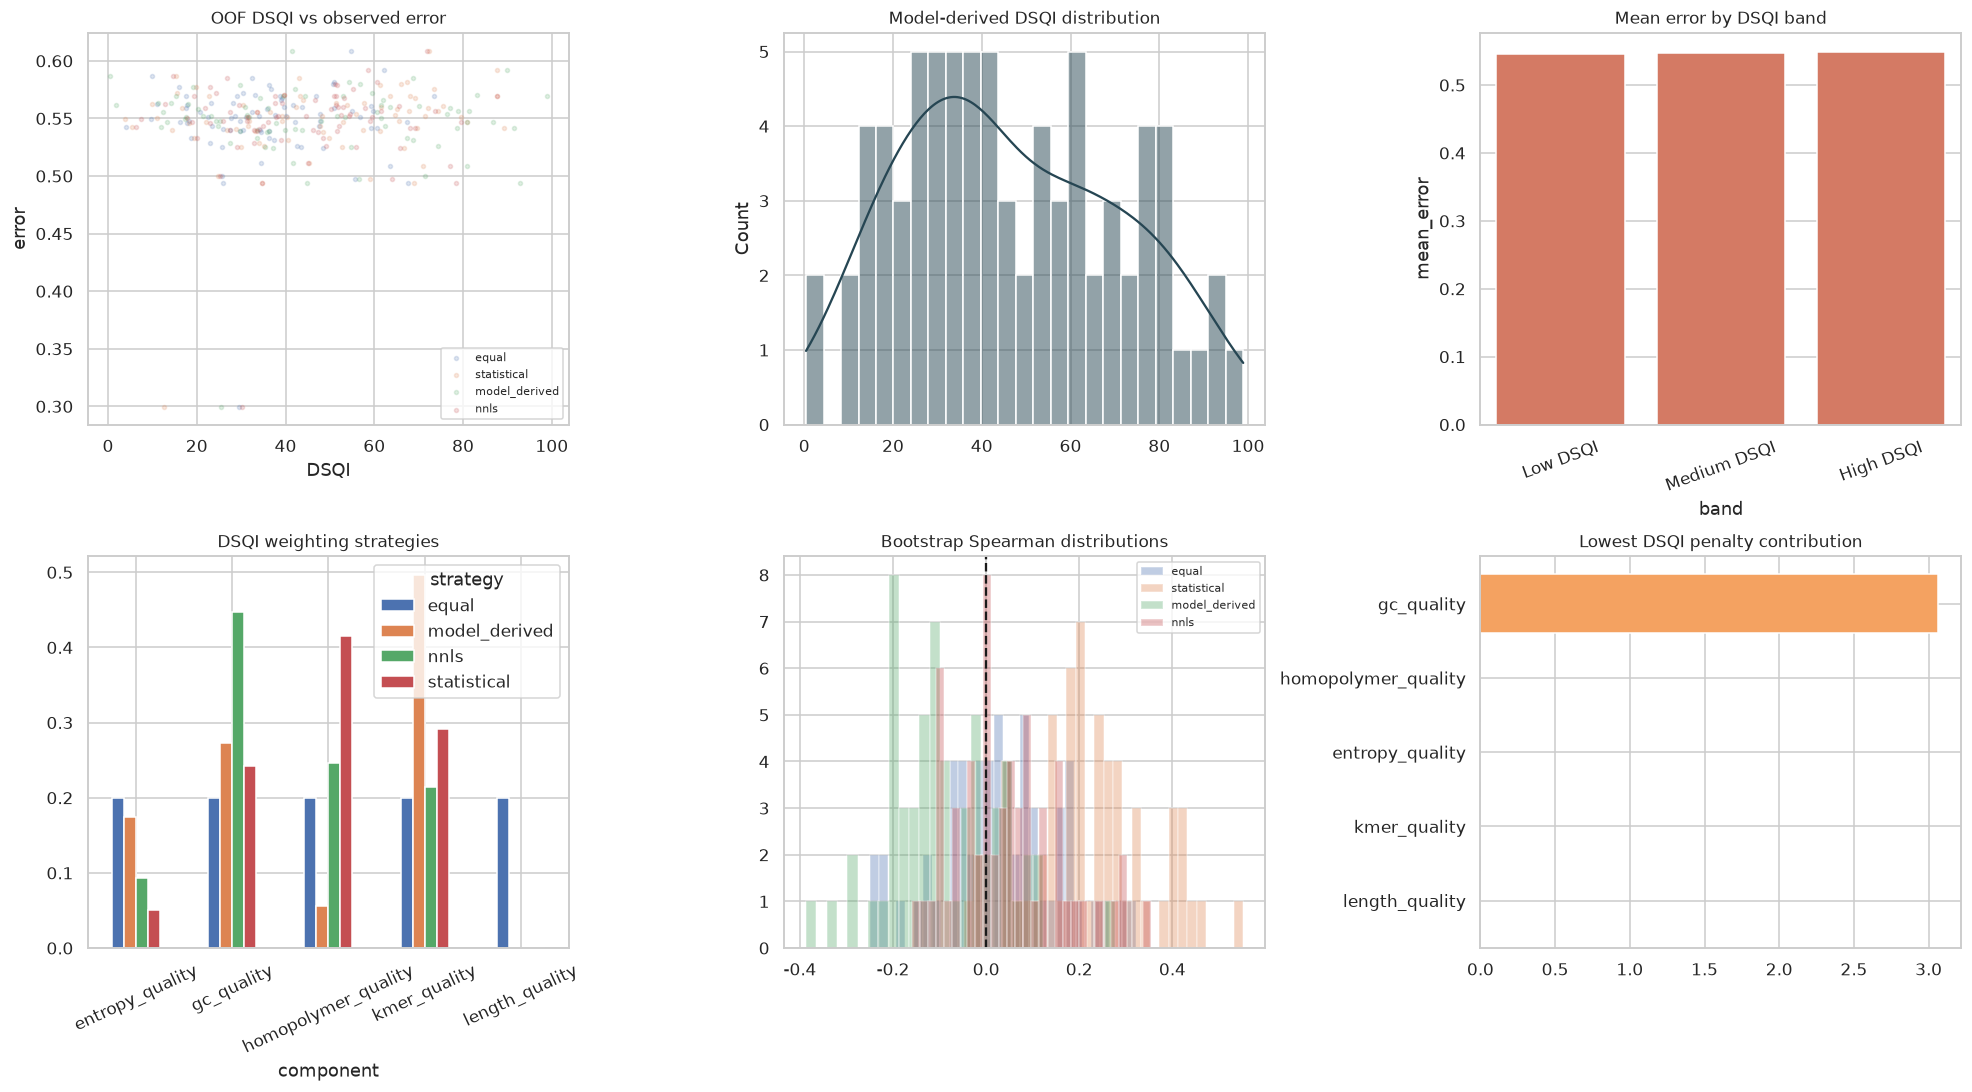

Lowest frozen-DSQI sequence: CNR_00028 score: 3.07


,component,quality,weight,penalty_points
0,gc_quality,0.887766,0.273147,3.065652
1,homopolymer_quality,1.000000,0.055962,0.000000
2,entropy_quality,1.000000,0.174466,0.000000
3,kmer_quality,1.000000,0.496425,0.000000
4,length_quality,1.000000,0.000000,0.000000


In [ ]:
dsqi_rows=[]; dsqi_boot={}
for name,v in dsqi_oof.items():
    rho=stats.spearmanr(v,Y).statistic; pr=stats.pearsonr(v,Y).statistic
    # Sign expectation is negative: higher DSQI should mean lower error.
    rng=np.random.default_rng(SEED+len(name)); bs=[]
    for _ in range(N_BOOT):
        idx=rng.integers(0,len(Y),len(Y)); bs.append(stats.spearmanr(v[idx],Y[idx]).statistic)
    bs=np.asarray(bs); dsqi_boot[name]=bs
    dsqi_rows.append({'strategy':name,'mean_dsqi':np.mean(v),'spearman_dsqi_error':rho,'pearson_dsqi_error':pr,
                      'spearman_lo':np.percentile(bs,2.5),'spearman_hi':np.percentile(bs,97.5)})
dsqi_results=pd.DataFrame(dsqi_rows); dsqi_results.to_csv(PROJECT_ROOT/'outputs/tables/dsqi_oof_results.csv',index=False); display(dsqi_results)

# Use model-derived OOF score for the main band table.
main_dsqi=dsqi_oof['model_derived']; bands=pd.qcut(main_dsqi,3,labels=['Low DSQI','Medium DSQI','High DSQI'],duplicates='drop')
band_pd=pd.DataFrame({'band':bands,'dsqi':main_dsqi,'error':Y}).groupby('band',observed=False).agg(n=('error','size'),mean_dsqi=('dsqi','mean'),mean_error=('error','mean'),median_error=('error','median'),sd_error=('error','std')).reset_index()
band_pd.to_csv(PROJECT_ROOT/'outputs/tables/dsqi_bands.csv',index=False); display(band_pd)

# Paired bootstrap DSQI improvement over equal weights.
d=paired_bootstrap_metric(Y,dsqi_oof['model_derived'],dsqi_oof['equal'],metric='Spearman'); print('Paired bootstrap difference in Spearman(model-derived vs equal):',d.mean(),np.percentile(d,[2.5,97.5]))

fig,ax=plt.subplots(2,3,figsize=(18,10))
for name,v in dsqi_oof.items(): ax[0,0].scatter(v,Y,s=7,alpha=.18,label=name)
ax[0,0].set_title('OOF DSQI vs observed error'); ax[0,0].set_xlabel('DSQI'); ax[0,0].set_ylabel('error'); ax[0,0].legend(fontsize=7)
sns.histplot(main_dsqi,bins=25,kde=True,ax=ax[0,1],color='#264653'); ax[0,1].set_title('Model-derived DSQI distribution')
sns.barplot(data=band_pd,x='band',y='mean_error',ax=ax[0,2],color='#e76f51'); ax[0,2].set_title('Mean error by DSQI band'); ax[0,2].tick_params(axis='x',rotation=20)
wp=weights_pd.pivot(index='component',columns='strategy',values='weight'); wp.plot(kind='bar',ax=ax[1,0]); ax[1,0].set_title('DSQI weighting strategies'); ax[1,0].tick_params(axis='x',rotation=25)
for s,v in dsqi_boot.items(): ax[1,1].hist(v,bins=30,alpha=.35,label=s)
ax[1,1].axvline(0,color='k',ls='--'); ax[1,1].set_title('Bootstrap Spearman distributions'); ax[1,1].legend(fontsize=7)
# Lowest-scoring explanation using frozen final weights.
low_i=int(np.argmin(analysis_pd.dsqi_model_derived.values)); contrib=pd.DataFrame({'component':COMPONENTS,'quality':Qall[low_i],'weight':final_weights['model_derived']}); contrib['penalty_points']=100*contrib.weight*(1-contrib.quality); contrib=contrib.sort_values('penalty_points',ascending=False); ax[1,2].barh(contrib.component[::-1],contrib.penalty_points[::-1],color='#f4a261'); ax[1,2].set_title('Lowest DSQI penalty contribution')
plt.tight_layout(); plt.savefig(PROJECT_ROOT/'outputs/figures/dsqi_validation.png',dpi=160,bbox_inches='tight'); plt.show()
print('Lowest frozen-DSQI sequence:',analysis_pd.iloc[low_i].sequence_id,'score:',round(analysis_pd.iloc[low_i].dsqi_model_derived,2)); display(contrib)
contrib.to_csv(PROJECT_ROOT/'outputs/tables/lowest_dsqi_explanation.csv',index=False)

## 19. Feature ablation ladder

**Why this step is used.** A full feature model can improve simply because it has more capacity. The nested ablation ladder separates the value of an industry screening rule, continuous rule variables, classical sequence features, and the FCGR/digital-image branch.

**Alternatives considered.** Comparing only full model versus GC-only is a straw-man baseline. Comparing only fixed-capacity models can handicap small feature sets. This notebook uses the same outer folds and the same estimator family; the ladder is interpreted with paired bootstrap intervals rather than by assuming that every increment must improve.

**Architecture view.**

```text
industry binary rule -> rule variables -> classical features -> all sequence features -> paired OOF deltas
```

,stage,n_features,MAE,RMSE,R2,Pearson,Spearman,R2_lo,R2_hi,delta_R2
0,L0a industry rule,1,0.020786,0.036803,-0.055143,-0.084603,-0.091530,-0.232236,-0.027871,NaN
1,L0b rule variables,2,0.022583,0.036895,-0.060390,0.136580,0.200989,-0.688960,0.042703,-0.005247
2,L1 classical,5,0.022747,0.037861,-0.116664,-0.002796,-0.012672,-0.750465,0.016779,-0.056274
3,L2 all design features,46,0.022408,0.038151,-0.133806,-0.043530,0.007755,-0.667984,-0.042131,-0.017142


,increment,delta_R2,lo,hi
0,L0b rule variables,-0.068119,-0.486402,0.093448
1,L1 classical,-0.083597,-0.414527,0.134302
2,L2 all design features,0.022104,-0.098019,0.225070


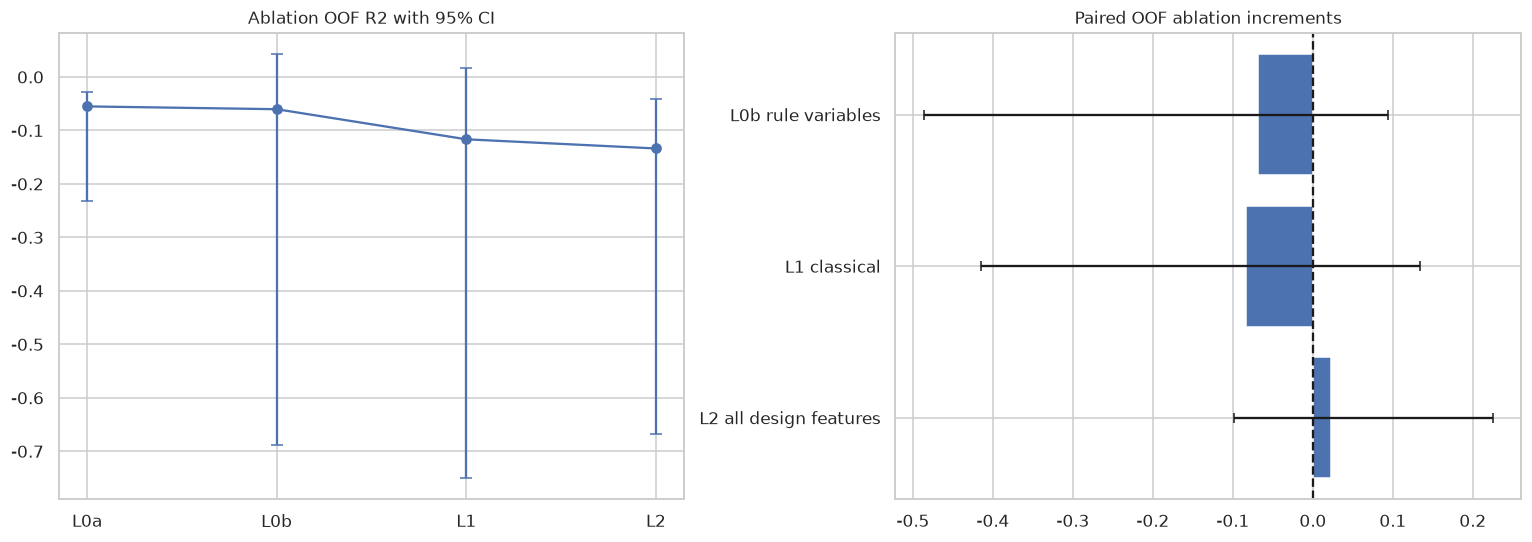

In [ ]:
# Use a compact, preregistered ladder to keep the comparison interpretable.
rule=( (analysis_pd.homopolymer_max<=3) & analysis_pd.gc_content.between(.45,.55) ).astype(float).values
ladder={
    'L0a industry rule':[None],
    'L0b rule variables':['gc_content','homopolymer_max'],
    'L1 classical':['gc_content','homopolymer_max','entropy_1mer','length','unique_kmer_ratio_3'],
    'L2 all design features':FEATURE_COLS,
}
abl_oof={}; abl_rows=[]
for name,cols in ladder.items():
    if cols==[None]: Xa=rule.reshape(-1,1)
    else: Xa=analysis_pd[cols].astype(float).fillna(0).values
    po=np.full(len(Y),np.nan)
    for tr,va in FOLDS:
        m=RandomForestRegressor(n_estimators=35,min_samples_leaf=3,random_state=SEED,n_jobs=-1).fit(Xa[tr],Y[tr]); po[va]=m.predict(Xa[va])
    abl_oof[name]=po; b=paired_bootstrap_metric(Y,po,metric='R2'); mm=regression_metrics(Y,po); abl_rows.append({'stage':name,'n_features':Xa.shape[1],**mm,'R2_lo':np.percentile(b,2.5),'R2_hi':np.percentile(b,97.5)})
abl_pd=pd.DataFrame(abl_rows); abl_pd['delta_R2']=abl_pd.R2.diff(); abl_pd.to_csv(PROJECT_ROOT/'outputs/tables/ablation_results.csv',index=False); display(abl_pd)
# Paired bootstrap for each nested increment.
sig=[]
for a,b in zip(list(ladder)[:-1],list(ladder)[1:]):
    d=paired_bootstrap_metric(Y,abl_oof[b],abl_oof[a],metric='R2'); sig.append({'increment':b,'delta_R2':d.mean(),'lo':np.percentile(d,2.5),'hi':np.percentile(d,97.5)})
sig_pd=pd.DataFrame(sig); sig_pd.to_csv(PROJECT_ROOT/'outputs/tables/ablation_paired_bootstrap.csv',index=False); display(sig_pd)
fig,ax=plt.subplots(1,2,figsize=(14,5)); ax[0].errorbar(range(len(abl_pd)),abl_pd.R2,yerr=[abl_pd.R2-abl_pd.R2_lo,abl_pd.R2_hi-abl_pd.R2],fmt='o-',capsize=4); ax[0].set_xticks(range(len(abl_pd))); ax[0].set_xticklabels(['L0a','L0b','L1','L2']); ax[0].set_title('Ablation OOF R2 with 95% CI'); ax[1].barh(sig_pd.increment[::-1],sig_pd.delta_R2[::-1],xerr=[sig_pd.delta_R2[::-1]-sig_pd.lo[::-1],sig_pd.hi[::-1]-sig_pd.delta_R2[::-1]],capsize=3); ax[1].axvline(0,color='k',ls='--'); ax[1].set_title('Paired OOF ablation increments'); plt.tight_layout(); plt.savefig(PROJECT_ROOT/'outputs/figures/ablation.png',dpi=160,bbox_inches='tight'); plt.show()

## 20. Optional recommendation on observed candidates

**Why this step is used.** The plan allows a recommendation component. The safe version ranks already observed sequences by the frozen DSQI and exposes the component contributions, rather than claiming that an untested edited sequence is experimentally reliable.

**Alternatives considered.** Simulated edits or annealed sequence repair can optimize a proxy while leaving real performance unknown. They are not presented as validated repairs here. Any prescriptive edit must be synthesized and sequenced before being called a quality improvement.

**Architecture view.**

```text
observed candidate sequences -> frozen DSQI -> rank -> inspect penalties -> experimental validation required
```

In [ ]:
recommendation_cols=['sequence_id','sequence','dsqi_model_derived','error_rate','gc_content','homopolymer_max','entropy_1mer','n_reads']
recommendations=analysis_pd.sort_values('dsqi_model_derived',ascending=False)[recommendation_cols].head(20)
recommendations.to_csv(PROJECT_ROOT/'outputs/tables/top_dsqi_candidates.csv',index=False)
print('Top observed candidates by frozen model-derived DSQI:'); display(recommendations)
print('This is a ranking of observed sequences, not evidence that an untested redesign will perform equally well.')

Top observed candidates by frozen model-derived DSQI:


,sequence_id,sequence,dsqi_model_derived,error_rate,gc_content,homopolymer_max,entropy_1mer,n_reads
2,CNR_00003,GCCCAAGGGTACGCCCGCAGCGACGCAATTGGCGGAGTAAGCGCGT...,93.592221,0.493584,0.663636,4,1.904548,12
25,CNR_00026,AATAGGTACATACAACCGCAGTATTGGTTGAATACTGACATAATCA...,90.417342,0.508463,0.390909,4,1.964350,15
28,CNR_00029,TACCCCAACGAATAGTACGCGAGGCCTGCGAACCCGTGAAGCACCA...,89.461403,0.569103,0.581818,8,1.894281,15
54,CNR_00057,ATCTGCATCGTGATCTGGCGGCCTAAGTCCGCTAACATTGGCGAGA...,77.285606,0.541531,0.545455,5,1.973208,15
29,CNR_00031,CGTTCAGCGGCACCGTACTCGGCGAGGTCGTGAGGCACGGTTATCA...,75.950871,0.546820,0.609091,6,1.962782,15
9,CNR_00010,TGGAAAGCACAACAATAAACAGGGGGCTTTACAAGCGTCGAAAGTT...,75.750943,0.592107,0.518182,5,1.939361,15
13,CNR_00014,ATACCGTAGCCCAGCGAAAACTCTGCCTCTGCGAACTATAATCTTC...,75.674412,0.497275,0.527273,4,1.955840,15
72,CNR_00075,GCGTATACGTGGCGTGGAGAGGCACACCGGGAATCAGTTCAGTAGG...,75.443622,0.558906,0.554545,4,1.974967,15
59,CNR_00062,TCGGGCAAGTCTCTGGCTATAAGCGCGTCTTAGTTAGTAGTTTTCG...,74.749234,0.556139,0.445455,4,1.966826,15
63,CNR_00066,GGGAGATGGAATGTGAACTGACTAGTTTGTTTCCCCCGCCTAATGG...,73.627825,0.556661,0.445455,5,1.974098,15


This is a ranking of observed sequences, not evidence that an untested redesign will perform equally well.


## 21. Final dashboard and visual inventory

**Why this step is used.** The final dashboard is a compact report entry point, while the earlier figures preserve detailed diagnostics. All figures are written to disk before delivery.

**Visual inventory.** Coverage histogram, target/error distribution and ECDF, GC distribution, homopolymer boxplots, GC/entropy/homopolymer scatterplots, pairplot, association table/plot, regression calibration and residuals, classification confusion/ROC/PR, PCA/UMAP, clustering silhouette, feature importance, graph diagnostics, DSQI distributions/bands/weights, and ablation intervals are all generated by the notebook.

**Architecture view.**

```text
metrics + tables + plots -> dashboard -> saved report artefacts -> final evidence summary
```

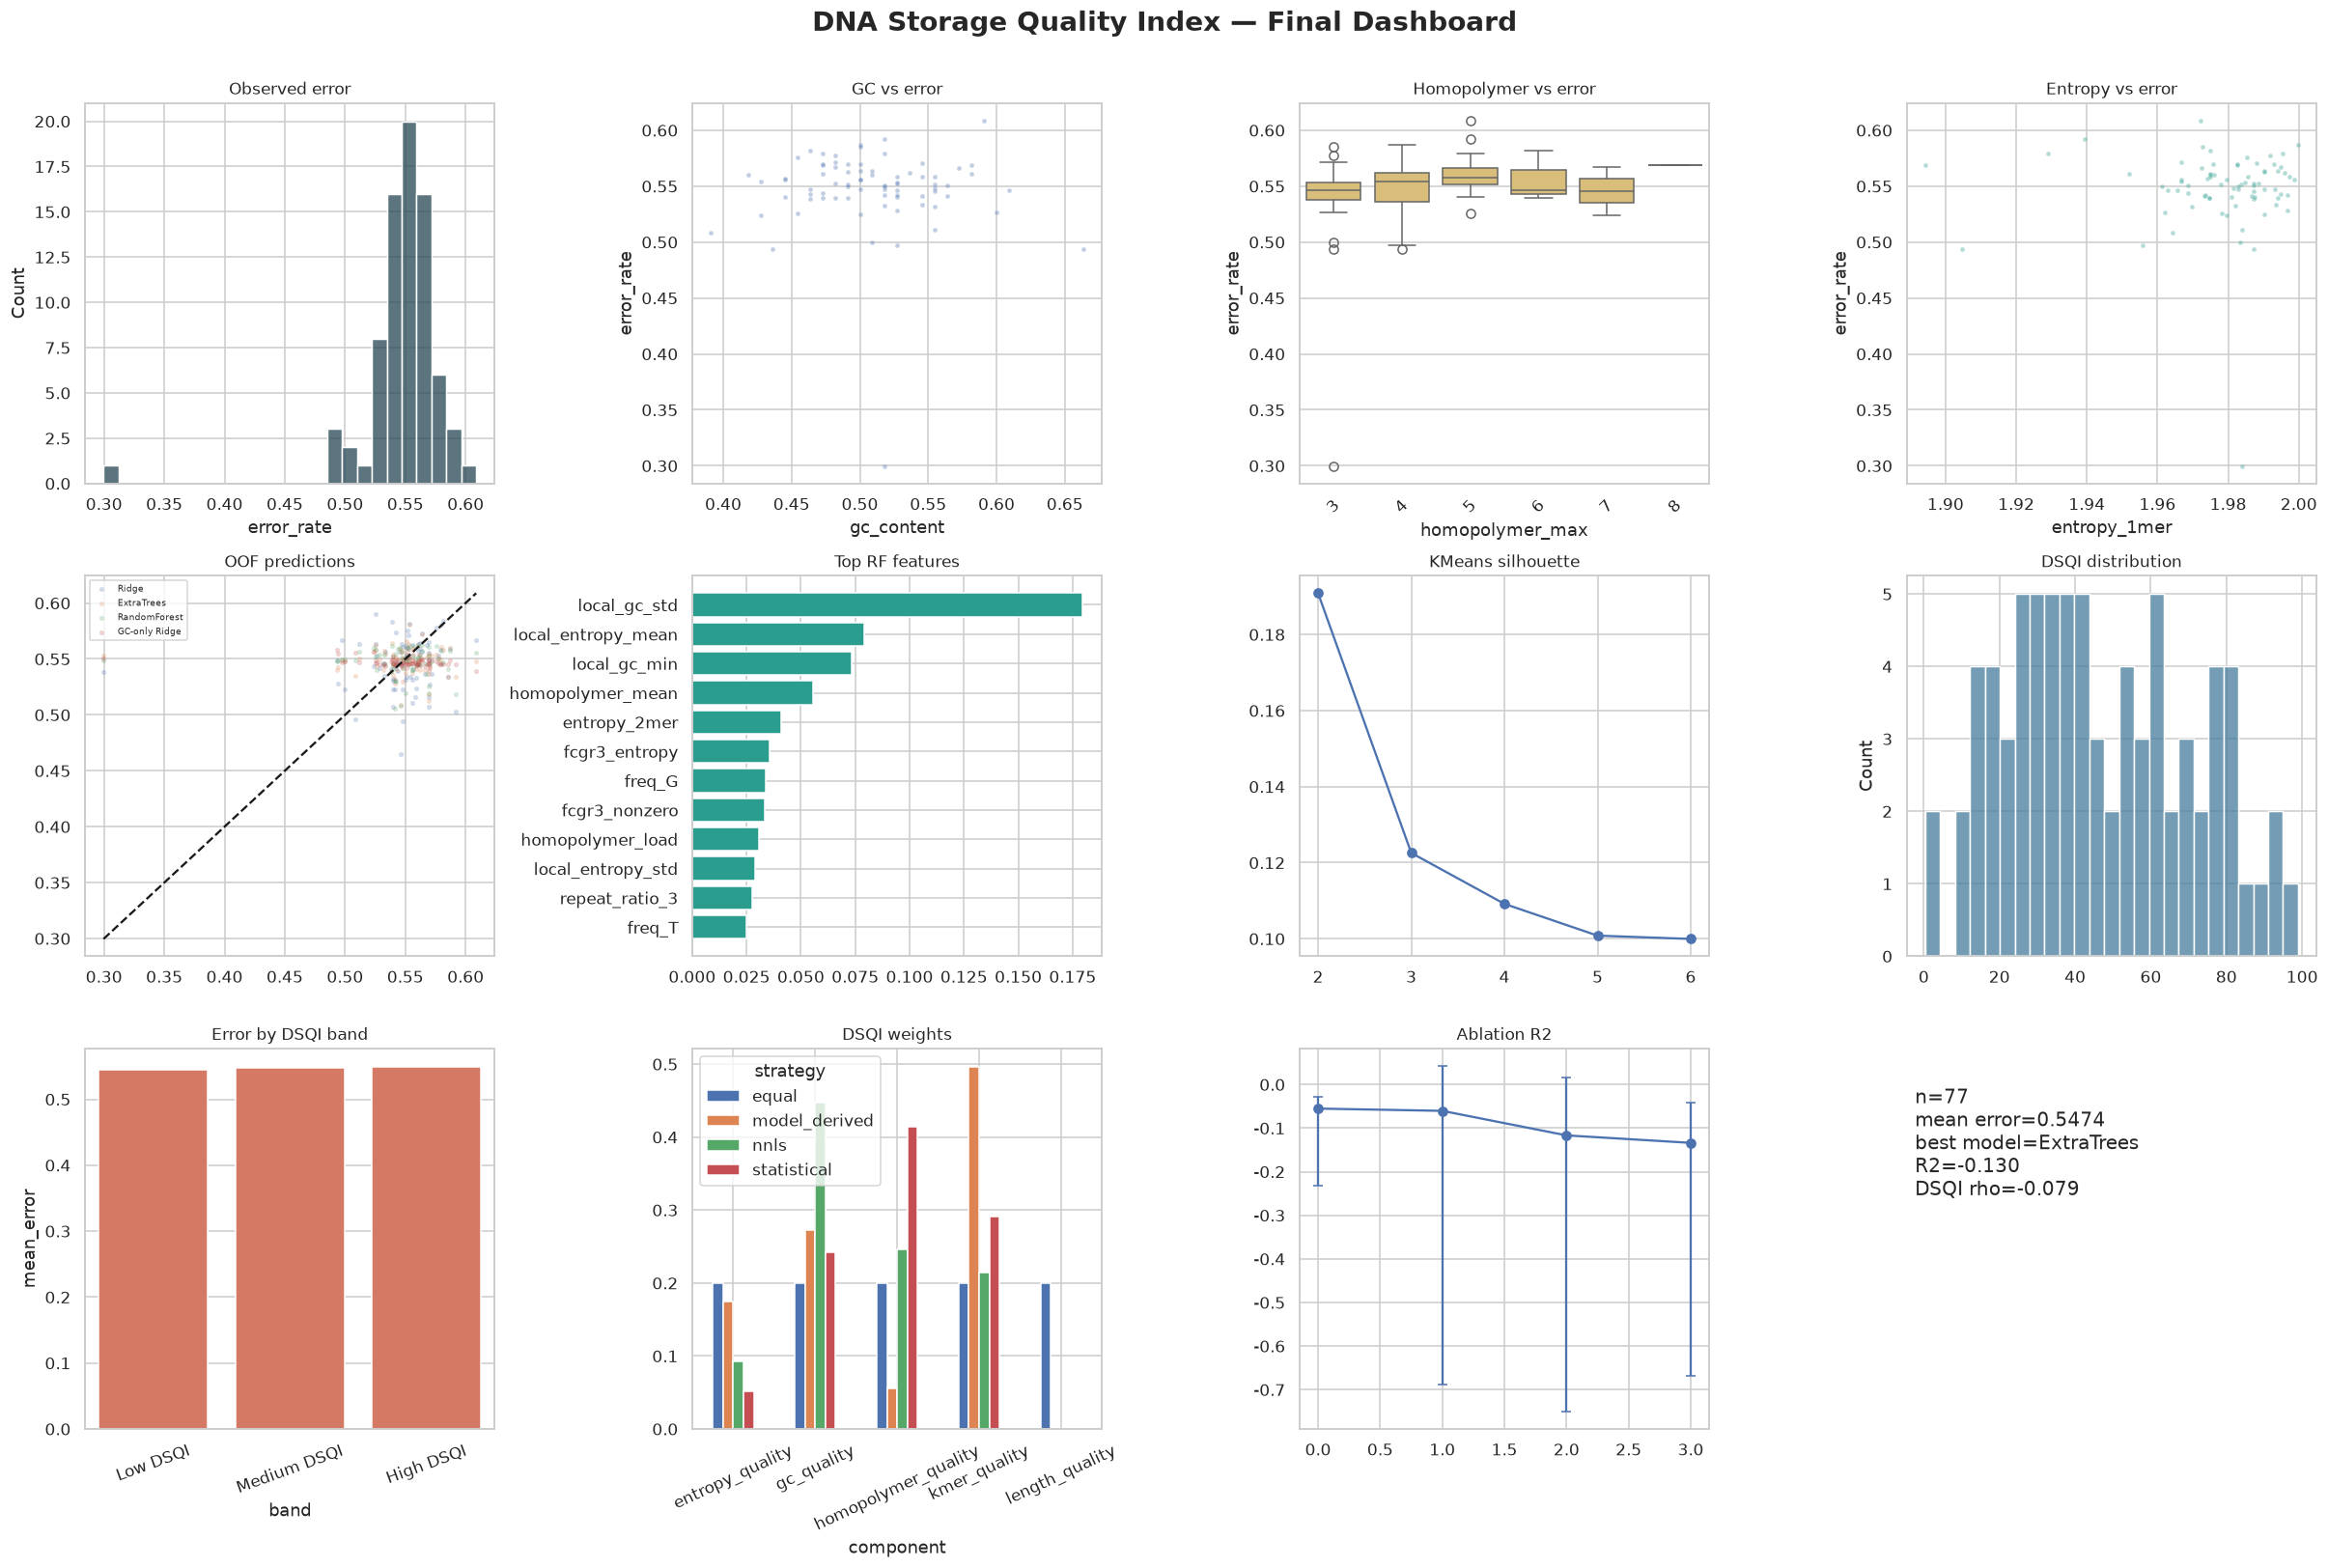

In [ ]:
fig,ax=plt.subplots(3,4,figsize=(22,15)); fig.suptitle('DNA Storage Quality Index — Final Dashboard',fontsize=18,fontweight='bold')
sns.histplot(analysis_pd.error_rate,bins=25,ax=ax[0,0],color='#264653'); ax[0,0].set_title('Observed error')
sns.scatterplot(data=analysis_pd,x='gc_content',y='error_rate',s=10,alpha=.35,ax=ax[0,1]); ax[0,1].set_title('GC vs error')
sns.boxplot(data=analysis_pd,x='homopolymer_max',y='error_rate',ax=ax[0,2],color='#e9c46a'); ax[0,2].tick_params(axis='x',rotation=45); ax[0,2].set_title('Homopolymer vs error')
sns.scatterplot(data=analysis_pd,x='entropy_1mer',y='error_rate',s=10,alpha=.35,ax=ax[0,3],color='#2a9d8f'); ax[0,3].set_title('Entropy vs error')
for name,p in OOF.items():
    if name not in ['Mean baseline']: ax[1,0].scatter(Y,p,s=6,alpha=.18,label=name)
ax[1,0].plot([Y.min(),Y.max()],[Y.min(),Y.max()],'k--'); ax[1,0].set_title('OOF predictions'); ax[1,0].legend(fontsize=6)
ax[1,1].barh(importance_pd.head(12).feature[::-1],importance_pd.head(12).rf_mean[::-1],color='#2a9d8f'); ax[1,1].set_title('Top RF features')
ax[1,2].plot(cluster_eval.k,cluster_eval.silhouette,'o-'); ax[1,2].set_title('KMeans silhouette')
sns.histplot(main_dsqi,bins=25,ax=ax[1,3],color='#457b9d'); ax[1,3].set_title('DSQI distribution')
sns.barplot(data=band_pd,x='band',y='mean_error',ax=ax[2,0],color='#e76f51'); ax[2,0].tick_params(axis='x',rotation=20); ax[2,0].set_title('Error by DSQI band')
wp.plot(kind='bar',ax=ax[2,1]); ax[2,1].set_title('DSQI weights'); ax[2,1].tick_params(axis='x',rotation=25)
ax[2,2].errorbar(range(len(abl_pd)),abl_pd.R2,yerr=[abl_pd.R2-abl_pd.R2_lo,abl_pd.R2_hi-abl_pd.R2],fmt='o-',capsize=3); ax[2,2].set_title('Ablation R2')
ax[2,3].axis('off'); ax[2,3].text(.02,.9,f'n={len(analysis_pd):,}\nmean error={Y.mean():.4f}\nbest model={best_model}\nR2={reg_results.set_index("model").loc[best_model,"R2"]:.3f}\nDSQI rho={dsqi_results.set_index("strategy").loc["model_derived","spearman_dsqi_error"]:.3f}',va='top',fontsize=13)
plt.tight_layout(rect=[0,0,1,.97]); plt.savefig(PROJECT_ROOT/'outputs/figures/final_dsqi_dashboard.png',dpi=180,bbox_inches='tight'); plt.show()

## 22. Reproducibility, output inventory, and external validation hook

**Why this step is used.** A research-grade notebook records the source, checksums, selected subset, thresholds, feature definitions, folds, software versions, and limitations. External validation is supported only when a genuinely labeled independent CSV is supplied.

**External CSV contract.** Required columns: `sequence_id`, `sequence`, `error_rate`; optional columns: `platform`, `read_count`. The external scoring cell applies the frozen DSQI formula without retraining. No external result is fabricated when the file is absent.

**Architecture view.**

```text
source checksums + config + software versions + metrics + figures -> manifest
optional independent labeled CSV -> same features -> frozen DSQI -> external correlation
```

In [ ]:
# External validation is deliberately opt-in through a user-provided labeled file.
EXTERNAL_CSV=PROJECT_ROOT/'data/external/external_labeled_sequences.csv'
external_status={'path':str(EXTERNAL_CSV),'available':EXTERNAL_CSV.exists(),'result':'pending'}
if EXTERNAL_CSV.exists():
    ext=pd.read_csv(EXTERNAL_CSV)
    required={'sequence_id','sequence','error_rate'}
    missing=required-set(ext.columns)
    if missing: raise ValueError('External CSV missing columns: '+str(sorted(missing)))
    # Reuse only sequence-derived feature definitions; no refitting on external labels.
    ext['sequence']=ext.sequence.astype(str).str.upper(); ext=ext[ext.sequence.map(lambda s:bool(s) and set(s)<=VALID)].copy()
    ext_rows=[]
    for r in ext.itertuples():
        f=sequence_features(r.sequence); f.update({'sequence_id':r.sequence_id,'sequence':r.sequence,'error_rate':float(r.error_rate)})
        ext_rows.append(f)
    extf=pd.DataFrame(ext_rows)
    # Use frozen all-data references for deployment scoring.
    extf['gc_deviation']=abs(extf.gc_content-analysis_pd.gc_content.median())
    Qext=[]
    # quality_matrix expects analysis_pd; compute the same fixed transformations explicitly.
    gc_scale=max(analysis_pd.gc_deviation.quantile(.90),.01); gcq=np.exp(-extf.gc_deviation/gc_scale)
    hpq=1-np.clip((extf.homopolymer_max-analysis_pd.homopolymer_max.quantile(.10))/max(analysis_pd.homopolymer_max.quantile(.90)-analysis_pd.homopolymer_max.quantile(.10),1e-9),0,1)
    enq=np.clip((extf.entropy_1mer-analysis_pd.entropy_1mer.quantile(.10))/max(analysis_pd.entropy_1mer.quantile(.90)-analysis_pd.entropy_1mer.quantile(.10),1e-9),0,1)
    kmq=np.clip((extf.unique_kmer_ratio_3-analysis_pd.unique_kmer_ratio_3.quantile(.10))/max(analysis_pd.unique_kmer_ratio_3.quantile(.90)-analysis_pd.unique_kmer_ratio_3.quantile(.10),1e-9),0,1)
    lq=np.clip(1-abs(extf.length-analysis_pd.length.median())/max(analysis_pd.length.quantile(.90)-analysis_pd.length.quantile(.10),1),0,1)
    Qext=np.column_stack([gcq,hpq,enq,kmq,lq]); extf['dsqi_model_derived']=100*(1-Qext@final_weights['model_derived'])
    rho=stats.spearmanr(extf.dsqi_model_derived,extf.error_rate).statistic
    external_status.update({'result':'computed','n':len(extf),'spearman_dsqi_error':float(rho)})
    pd.DataFrame([external_status]).to_csv(PROJECT_ROOT/'outputs/tables/external_validation.csv',index=False); display(pd.DataFrame([external_status]))
else:
    print('External validation pending; no labeled independent file supplied.')
    print('Expected path:',EXTERNAL_CSV)

config={'project':'DSQI complete','dataset':'Microsoft CNR public benchmark','real_data_required':True,'max_centers':MAX_CENTERS,
        'max_reads_per_center':MAX_READS_PER_CENTER,'primary_min_reads':PRIMARY_MIN_READS,'primary_reducer':PRIMARY_REDUCER,
        'n_folds':N_FOLDS,'n_bootstrap':N_BOOT,'seed':SEED,'graph_n':GRAPH_N,'feature_columns':FEATURE_COLS,
        'metric_definitions':{'target':'mean normalized global Levenshtein distance','regression':'MAE, RMSE, R2, Pearson, Spearman','classification':'accuracy, balanced accuracy, macro precision/recall/F1, macro ROC-AUC, macro PR-AUC','clustering':'silhouette'},
        'limitations':['Spark is local mode in Colab, not a multi-node cluster.','CNR subset is bounded when MAX_CENTERS is not None.','Error target is a read-to-reference proxy.','Graph uses bounded top-k sampling.','DSQI requires external experimental validation before deployment.']}
with open(PROJECT_ROOT/'outputs/experiment_config.json','w') as f: json.dump(config,f,indent=2,default=str)
inv=[]
for p in sorted((PROJECT_ROOT/'outputs').rglob('*')):
    if p.is_file(): inv.append({'path':str(p.relative_to(PROJECT_ROOT)),'size_bytes':p.stat().st_size})
inventory=pd.DataFrame(inv); inventory.to_csv(PROJECT_ROOT/'outputs/tables/output_inventory.csv',index=False); display(inventory)

External validation pending; no labeled independent file supplied.
Expected path: /home/ubuntu/DSQI_complete_smoke/data/external/external_labeled_sequences.csv


,path,size_bytes
0,outputs/experiment_config.json,1886
1,outputs/figures/ablation.png,65965
2,outputs/figures/classification_diagnostics.png,147160
3,outputs/figures/clustering_structure.png,146482
4,outputs/figures/dsqi_validation.png,292904
5,outputs/figures/eda_matrix.png,416389
6,outputs/figures/feature_importance.png,128520
7,outputs/figures/final_dsqi_dashboard.png,558050
8,outputs/figures/graph_diagnostics.png,92351
9,outputs/figures/pairplot_features.png,177096


## 23. Metric validation and quality gates

**Why this step is used.** Correct-looking tables are not enough. This section recomputes core definitions and checks metric ranges, out-of-fold coverage, probability normalization, DSQI bounds, leakage guards, and required artefacts before the final conclusions are printed.

**Alternatives considered.** Manual inspection can miss a sign reversal, a shape error, or a stale output. Automated assertions are selected because they fail loudly and can be rerun after every configuration change.

**Architecture view.**

```text
raw definitions + OOF arrays + exported tables -> invariants -> pass/fail report -> final conclusions
```

In [ ]:
metric_checks={}
def check(name, condition, detail=''):
    metric_checks[name]={'passed':bool(condition),'detail':detail}
    assert condition, f'Metric quality gate failed: {name} :: {detail}'

check('Levenshtein_identity',levenshtein_py('ACGT','ACGT')==0)
check('Levenshtein_substitution',levenshtein_py('ACGT','ACGA')==1)
check('normalized_target_bounds',bool(np.all((analysis_pd.error_rate>=0)&(analysis_pd.error_rate<=1))))
check('OOF_complete',all(np.isfinite(v).all() for v in OOF.values()))
check('OOF_metric_finite',bool(np.isfinite(reg_results[['MAE','RMSE','R2']].values).all()))
check('RMSE_not_below_MAE_for_nonnegative_errors',all(r.RMSE+1e-12>=r.MAE for _,r in reg_results.iterrows()))
check('classification_labels_valid',all(np.isin(o['true'],[0,1,2])) and all(np.isin(o['pred'],[0,1,2])))
check('classification_probabilities_normalized',bool(np.allclose(np.nansum(o['prob'],axis=1),1,atol=1e-6)))
check('classification_auc_range',bool(np.all((cls_results[['macro_ROC_AUC','macro_PR_AUC']].values>=0)&(cls_results[['macro_ROC_AUC','macro_PR_AUC']].values<=1))))
check('DSQI_bounds',all(np.nanmin(v)>=-1e-6 and np.nanmax(v)<=100+1e-6 for v in dsqi_oof.values()))
check('No_forbidden_model_features',not (set(FEATURE_COLS)&FORBIDDEN),str(set(FEATURE_COLS)&FORBIDDEN))
check('No_duplicate_sequence_rows',analysis_pd.sequence.nunique()==len(analysis_pd))
required_outputs=['oof_regression_results.csv','oof_classification_results.csv','dsqi_oof_results.csv','dsqi_weights.csv','ablation_results.csv','final_dsqi_dashboard.png']
for f in required_outputs: check('artifact_'+f,(PROJECT_ROOT/'outputs/tables'/f).exists() or (PROJECT_ROOT/'outputs/figures'/f).exists())
with open(PROJECT_ROOT/'outputs/metric_validation_report.json','w') as f: json.dump(metric_checks,f,indent=2,default=str)
print('All metric quality gates passed:',len(metric_checks))

All metric quality gates passed: 18


## 24. Final evidence summary and reporting rules

The final interpretation must follow the evidence, not the desired hypothesis. A negative DSQI–error association supports the intended ordering; a weak, null, or positive association is a result that must be reported plainly. Model performance above the GC-only baseline is meaningful only with its paired interval and only for the fixed target and selected data subset.

**Architecture view.**

```text
all exported metrics -> compare uncertainty -> state supported findings -> state limitations -> no unsupported causal claim
```

In [ ]:
print('='*88)
print('DSQI FINAL EVIDENCE SUMMARY')
print('='*88)
print(f'Analytical clusters: {len(analysis_pd):,}')
print(f'Primary target: {PRIMARY_REDUCER} normalized global Levenshtein, min_reads={PRIMARY_MIN_READS}')
print(f'Mean observed error: {Y.mean():.6f}; median: {np.median(Y):.6f}')
print('\nOOF regression leaderboard:')
display(reg_results[['model','MAE','RMSE','R2','R2_lo','R2_hi','Spearman','Spearman_lo','Spearman_hi']])
print('\nOOF classification leaderboard:'); display(cls_results)
print('\nDSQI validation:'); display(dsqi_results)
print('\nRequired reporting rule: do not claim causation from these observational sequence-level associations.')
print('Required external-validation rule: do not claim generalization until a labeled independent dataset is scored.')

DSQI FINAL EVIDENCE SUMMARY
Analytical clusters: 77
Primary target: mean normalized global Levenshtein, min_reads=8
Mean observed error: 0.547406; median: 0.551632

OOF regression leaderboard:


,model,MAE,RMSE,R2,R2_lo,R2_hi,Spearman,Spearman_lo,Spearman_hi
3,Mean baseline,0.019481,0.035947,-0.006638,-0.069228,-0.000146,NaN,NaN,NaN
4,GC-only Ridge,0.020687,0.037163,-0.075855,-0.257554,-0.041259,-0.246697,-0.425591,-0.026845
1,ExtraTrees,0.022796,0.038084,-0.129866,-0.638246,-0.051685,0.025606,-0.171905,0.299290
2,RandomForest,0.022408,0.038151,-0.133806,-0.667984,-0.042131,0.007755,-0.240687,0.243601
0,Ridge,0.026105,0.040881,-0.301878,-1.725914,-0.046493,0.145880,-0.086223,0.355479



OOF classification leaderboard:


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_F1,macro_ROC_AUC,macro_PR_AUC
0,LogisticRegression,0.441558,0.442051,0.445699,0.442051,0.439959,0.571885,0.430005
1,RandomForestClassifier,0.350649,0.351282,0.349725,0.351282,0.349414,0.543690,0.396156



DSQI validation:


,strategy,mean_dsqi,spearman_dsqi_error,pearson_dsqi_error,spearman_lo,spearman_hi
0,equal,36.377171,0.027486,0.023769,-0.231627,0.275121
1,statistical,47.030053,0.196476,0.222679,-0.013472,0.453516
2,model_derived,46.430688,-0.079119,-0.005775,-0.308385,0.113217
3,nnls,43.654164,0.029563,0.046125,-0.127924,0.294943



Required reporting rule: do not claim causation from these observational sequence-level associations.
Required external-validation rule: do not claim generalization until a labeled independent dataset is scored.


## References

[1] Microsoft, **Clustered Nanopore Reads Dataset** — data description, positional alignment of centers and clusters, sequencing context, and release caveat. <https://github.com/microsoft/clustered-nanopore-reads-dataset>

[2] Itai Orr et al., **Deep-DNA-based-storage / DNAformer repository** — public implementation and note that full datasets are shared on request. <https://github.com/itaiorr/Deep-DNA-based-storage>

[3] Daniella Bar-Lev et al., **Scalable and Robust DNA-based Storage via Coding Theory and Deep Learning**. <https://nvmw.ucsd.edu/nvmw2025-program/nvmw2025-final9.pdf>

[4] Apache Spark, **PySpark API Documentation**. <https://spark.apache.org/docs/latest/api/python/>

[5] Apache Spark, **GraphX Programming Guide**. <https://spark.apache.org/docs/latest/graphx-programming-guide.html>

[6] scikit-learn, **Model Evaluation and Inspection**. <https://scikit-learn.org/stable/modules/model_evaluation.html>